# RAIDS-NIDS Jupyter starter

In [ ]:
from pathlib import Path
import os
import sys

PROJECT = Path(r"C:\Users\ASUS\raids-nids")

assert (PROJECT / "pyproject.toml").exists(), "pyproject.toml not found"
assert (PROJECT / "src" / "raids_nids").exists(), "Package source not found"

os.chdir(PROJECT)
sys.path.insert(0, str(PROJECT / "src"))

print("Project:", PROJECT)
print("Package source:", PROJECT / "src" / "raids_nids")

Project: C:\Users\ASUS\raids-nids
Package source: C:\Users\ASUS\raids-nids\src\raids_nids


## Install the project into this notebook kernel

Run this once. If Jupyter asks for a kernel restart, restart the kernel and rerun the first cell.

In [2]:
# %pip install -e ".[dev]"

Obtaining file:///C:/Users/ASUS/raids-nids
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for raids-nids (pyproject.toml): started
  Building editable for raids-nids (pyproject.toml): finished with status 'done'
  Created wheel for raids-nids: filename=raids_nids-0.1.1-0.editable-py3-none-any.whl size=3506 sha256=0c77493ced51c0a6a0834acdbcfb556479633a7072a950b8fb9f89fd8e2fdfa8
  Stored in directory: C:\Users\ASUS\AppData\Local\Temp\pip-ephem-wheel-cache-0j9jisdj\wheels\60\06\8b\f47b93d709e2c34b3e618d4f0acd90b3f6c5c8169b11c95d

## Generate engineering-only synthetic data

In [3]:
from raids_nids.synthetic import generate_synthetic

source_path, target_path = generate_synthetic(
    PROJECT / "data" / "synthetic",
    seed=11
)

print("Created:", source_path)
print("Created:", target_path)

Created: C:\Users\ASUS\raids-nids\data\synthetic\source.csv
Created: C:\Users\ASUS\raids-nids\data\synthetic\target.csv


## Audit both datasets

In [4]:
from raids_nids.audit import audit_dataset
from IPython.display import display
import pandas as pd

source_audit = audit_dataset(
    PROJECT / "configs" / "datasets" / "synthetic_source.yaml",
    PROJECT / "results" / "audits" / "Synthetic-Source-Smoke.json",
)
target_audit = audit_dataset(
    PROJECT / "configs" / "datasets" / "synthetic_target.yaml",
    PROJECT / "results" / "audits" / "Synthetic-Target-Smoke.json",
)
display(pd.DataFrame([source_audit, target_audit])[
    ["dataset", "rows_audited", "usable_features", "exact_duplicate_rows"]
] )

,dataset,rows_audited,usable_features,exact_duplicate_rows
0,Synthetic-Source-Smoke,3000,20,0
1,Synthetic-Target-Smoke,4000,20,0


## Run static and adaptive experiments

Each run writes its configuration, summary, window trace, environment and trained model under `results/runs`.

In [5]:
from pathlib import Path
import importlib
import sys

runner_file = PROJECT / "src" / "raids_nids" / "runner.py"
text = runner_file.read_text(encoding="utf-8")

text = text.replace(
    "import resource\n",
    """try:
    import resource
except ImportError:
    resource = None
"""
)

text = text.replace(
    '"peak_process_memory_mb": resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024.0,',
    '"peak_process_memory_mb": '
    '(resource.getrusage(resource.RUSAGE_SELF).ru_maxrss / 1024.0 '
    'if resource is not None else None),'
)

runner_file.write_text(text, encoding="utf-8")

sys.modules.pop("raids_nids.runner", None)
importlib.invalidate_caches()

print("Windows compatibility fix applied:", runner_file)

Windows compatibility fix applied: C:\Users\ASUS\raids-nids\src\raids_nids\runner.py


In [6]:
from pathlib import Path
import importlib
import sys

runner_file = PROJECT / "src" / "raids_nids" / "runner.py"
text = runner_file.read_text(encoding="utf-8")

# Clean anything inserted between the standard imports.
start = text.index("import re") + len("import re")
end = text.index("import sys", start)
text = text[:start] + "\n" + text[end:]

# Reconstruct the cross-platform resource import.
sklearn_marker = (
    "from sklearn.model_selection import "
    "StratifiedGroupKFold, train_test_split"
)
package_marker = "from .adaptation import select_queries"

start = text.index(sklearn_marker) + len(sklearn_marker)
end = text.index(package_marker, start)

resource_block = """

try:
    import resource
except ImportError:  # resource is unavailable on Windows.
    resource = None

"""

text = text[:start] + resource_block + text[end:]

# Verify syntax before replacing the file.
compile(text, str(runner_file), "exec")
runner_file.write_text(text, encoding="utf-8")

sys.modules.pop("raids_nids.runner", None)
importlib.invalidate_caches()

print("runner.py repaired successfully")

runner.py repaired successfully


In [7]:
from raids_nids.runner import run_experiment

print("Import successful")

Import successful


In [8]:
from raids_nids.runner import run_experiment
import pandas as pd
from IPython.display import display

static_summary = run_experiment(
    PROJECT / "configs" / "experiments" / "smoke_static.yaml"
)

adaptive_summary = run_experiment(
    PROJECT / "configs" / "experiments" / "smoke_adaptive.yaml"
)

display(pd.DataFrame([static_summary, adaptive_summary])[
    [
        "method",
        "labels_queried",
        "label_budget_ceiling",
        "mean_known_macro_f1",
        "mean_novel_auprc",
        "primary_normalized_recovery_area",
    ]
])

,method,labels_queried,label_budget_ceiling,mean_known_macro_f1,mean_novel_auprc,primary_normalized_recovery_area
0,logistic_open_set,0,0,0.967887,0.986526,1.000000
1,adaptive_prototype_1pct,35,40,0.946437,0.455887,0.986206


## Aggregate completed runs

In [9]:
from raids_nids.aggregate import aggregate_results

aggregation = aggregate_results(PROJECT / "results" / "runs", PROJECT / "results" / "aggregate")
print(aggregation)
display(pd.read_csv(PROJECT / "results" / "aggregate" / "method_ranking.csv"))

{'runs': 2, 'methods': 2, 'complete_blocks': 1}


,method,n_runs,mean,std,median,bootstrap_95_low,bootstrap_95_high
0,logistic_open_set,1,1.000000,0.0,1.000000,1.000000,1.000000
1,adaptive_prototype_1pct,1,0.986206,0.0,0.986206,0.986206,0.986206


## Check integrity tests

In [10]:
import subprocess

subprocess.run([sys.executable, "-m", "pytest", "-q"], cwd=PROJECT, check=True)

CompletedProcess(args=['C:\\Users\\ASUS\\anaconda3\\envs\\raids-nids\\python.exe', '-m', 'pytest', '-q'], returncode=0)

## Next step for real data

Do not run the full matrix yet. First place licensed dataset files under `data/raw`, verify every dataset YAML, run the audits, and freeze the label/time/leakage decisions in `docs/dataset_decision_log.csv`.

In [11]:
RAW = PROJECT / "data" / "raw"
RAW.mkdir(parents=True, exist_ok=True)

print("Place extracted CSV files here:")
print(RAW)

Place extracted CSV files here:
C:\Users\ASUS\raids-nids\data\raw


In [12]:
import pandas as pd

csv_files = list(RAW.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {RAW}")

for file in csv_files:
    preview = pd.read_csv(file, nrows=5, low_memory=False)

    print("\nFILE:", file.name)
    print("SIZE (GB):", round(file.stat().st_size / (1024**3), 3))
    print("NUMBER OF COLUMNS:", len(preview.columns))
    print("COLUMNS:")
    print(preview.columns.tolist())

    for candidate in ["Attack", "Label", "attack", "label"]:
        if candidate in preview.columns:
            print(f"\n{candidate} sample values:")
            print(preview[candidate].tolist())


FILE: NetFlow_v3_Features.csv
SIZE (GB): 0.0
NUMBER OF COLUMNS: 2
COLUMNS:
['Feature', 'Description']

FILE: NF-UNSW-NB15-v3.csv
SIZE (GB): 0.538
NUMBER OF COLUMNS: 55
COLUMNS:
['FLOW_START_MILLISECONDS', 'FLOW_END_MILLISECONDS', 'IPV4_SRC_ADDR', 'L4_SRC_PORT', 'IPV4_DST_ADDR', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES', 'IN_PKTS', 'OUT_BYTES', 'OUT_PKTS', 'TCP_FLAGS', 'CLIENT_TCP_FLAGS', 'SERVER_TCP_FLAGS', 'FLOW_DURATION_MILLISECONDS', 'DURATION_IN', 'DURATION_OUT', 'MIN_TTL', 'MAX_TTL', 'LONGEST_FLOW_PKT', 'SHORTEST_FLOW_PKT', 'MIN_IP_PKT_LEN', 'MAX_IP_PKT_LEN', 'SRC_TO_DST_SECOND_BYTES', 'DST_TO_SRC_SECOND_BYTES', 'RETRANSMITTED_IN_BYTES', 'RETRANSMITTED_IN_PKTS', 'RETRANSMITTED_OUT_BYTES', 'RETRANSMITTED_OUT_PKTS', 'SRC_TO_DST_AVG_THROUGHPUT', 'DST_TO_SRC_AVG_THROUGHPUT', 'NUM_PKTS_UP_TO_128_BYTES', 'NUM_PKTS_128_TO_256_BYTES', 'NUM_PKTS_256_TO_512_BYTES', 'NUM_PKTS_512_TO_1024_BYTES', 'NUM_PKTS_1024_TO_1514_BYTES', 'TCP_WIN_MAX_IN', 'TCP_WIN_MAX_OUT', 'ICMP_TYPE', 'ICMP_I

In [13]:
from collections import Counter
import numpy as np
import pandas as pd

dataset_file = PROJECT / "data" / "raw" / "NF-UNSW-NB15-v3.csv"

attack_counts = Counter()
binary_counts = Counter()

total_rows = 0
missing_time = 0
time_order_violations = 0
previous_time = None

required_columns = [
    "FLOW_START_MILLISECONDS",
    "FLOW_END_MILLISECONDS",
    "Label",
    "Attack",
]

for chunk in pd.read_csv(
    dataset_file,
    usecols=required_columns,
    chunksize=250_000,
    low_memory=False,
):
    total_rows += len(chunk)

    attack_counts.update(chunk["Attack"].astype(str))
    binary_counts.update(chunk["Label"].astype(str))

    times = pd.to_numeric(
        chunk["FLOW_START_MILLISECONDS"],
        errors="coerce"
    )

    missing_time += int(times.isna().sum())
    valid_times = times.dropna().to_numpy()

    if len(valid_times):
        time_order_violations += int(
            np.count_nonzero(np.diff(valid_times) < 0)
        )

        if previous_time is not None and valid_times[0] < previous_time:
            time_order_violations += 1

        previous_time = valid_times[-1]

print("Total rows:", total_rows)
print("Missing timestamps:", missing_time)
print("Time-order violations:", time_order_violations)

print("\nMulticlass distribution:")
display(
    pd.DataFrame(
        attack_counts.items(),
        columns=["Attack", "Count"]
    ).sort_values("Count", ascending=False)
)

print("\nBinary distribution:")
display(
    pd.DataFrame(
        binary_counts.items(),
        columns=["Label", "Count"]
    ).sort_values("Label")
)

Total rows: 2365424
Missing timestamps: 0
Time-order violations: 335443

Multiclass distribution:


,Attack,Count
0,Benign,2237731
2,Exploits,42748
1,Fuzzers,33816
5,Generic,19651
4,Reconnaissance,17074
6,DoS,5980
3,Backdoor,4659
7,Shellcode,2381
8,Analysis,1226
9,Worms,158



Binary distribution:


,Label,Count
0,0,2237731
1,1,127693


In [14]:
import yaml

config = {
    "name": "NF-UNSW-NB15-v3",
    "path": "data/raw/NF-UNSW-NB15-v3.csv",
    "label_column": "Attack",
    "extra_label_columns": ["Label"],
    "time_column": "FLOW_START_MILLISECONDS",
    "drop_columns": [
        "FLOW_END_MILLISECONDS",
        "IPV4_SRC_ADDR",
        "IPV4_DST_ADDR",
    ],
    "auto_drop_identifiers": True,
    "sampling": {
        "max_rows": 500_000,
        "mode": "stratified",
        "seed": 11,
    },
}

config_path = (
    PROJECT
    / "configs"
    / "datasets"
    / "nf_unsw_nb15_v3.yaml"
)

config_path.parent.mkdir(parents=True, exist_ok=True)

with config_path.open("w", encoding="utf-8") as file:
    yaml.safe_dump(config, file, sort_keys=False)

print("Configuration created:", config_path)

Configuration created: C:\Users\ASUS\raids-nids\configs\datasets\nf_unsw_nb15_v3.yaml


In [15]:
from raids_nids.audit import audit_dataset

audit_output = (
    PROJECT
    / "results"
    / "audits"
    / "NF-UNSW-NB15-v3.json"
)

audit_report = audit_dataset(
    config_path,
    audit_output
)

display(pd.DataFrame({
    "Item": [
        "Rows audited",
        "Usable features",
        "Exact duplicate rows",
        "Duplicate feature rows",
        "Numeric features",
        "Categorical features",
        "Time available",
    ],
    "Value": [
        audit_report["rows_audited"],
        audit_report["usable_features"],
        audit_report["exact_duplicate_rows"],
        audit_report["duplicate_feature_rows"],
        audit_report["numeric_features"],
        audit_report["categorical_features"],
        audit_report["time_column_available"],
    ],
}))

,Item,Value
0,Rows audited,500000
1,Usable features,48
2,Exact duplicate rows,2
3,Duplicate feature rows,34184
4,Numeric features,48
5,Categorical features,0
6,Time available,True


In [16]:
print("Missing values:")
print(audit_report["columns_with_missing"])

print("\nInfinite values:")
print(audit_report["columns_with_infinity"])

print("\nConstant features:")
print(audit_report["constant_features"])

print("\nNear-unique features:")
print(audit_report["near_unique_features"])

print("\nSuspicious retained features:")
print(audit_report["suspicious_retained_features"])

Missing values:
{'SRC_TO_DST_SECOND_BYTES': 12963}

Infinite values:
{'SRC_TO_DST_SECOND_BYTES': 12376, 'DST_TO_SRC_SECOND_BYTES': 25339}

Constant features:
[]

Near-unique features:
[]

Suspicious retained features:
[]


In [ ]:
# 1. Examine class distribution through time

In [17]:
import numpy as np
import pandas as pd

dataset_file = (
    PROJECT
    / "data"
    / "raw"
    / "NF-UNSW-NB15-v3.csv"
)

temporal = pd.read_csv(
    dataset_file,
    usecols=["FLOW_START_MILLISECONDS", "Attack"],
    low_memory=False,
)

temporal["FLOW_START_MILLISECONDS"] = pd.to_numeric(
    temporal["FLOW_START_MILLISECONDS"],
    errors="coerce",
)

temporal = temporal.sort_values(
    "FLOW_START_MILLISECONDS",
    kind="mergesort",
).reset_index(drop=True)

# Ten equal-sized chronological partitions
number_of_bins = 10
temporal["time_decile"] = (
    np.arange(len(temporal)) * number_of_bins // len(temporal) + 1
)

count_table = pd.crosstab(
    temporal["time_decile"],
    temporal["Attack"],
)

percentage_table = (
    count_table
    .div(count_table.sum(axis=1), axis=0)
    .mul(100)
    .round(3)
)

print("CLASS COUNTS BY CHRONOLOGICAL DECILE")
display(count_table)

print("CLASS PERCENTAGES BY CHRONOLOGICAL DECILE")
display(percentage_table)

class_periods = (
    temporal.groupby("Attack")["FLOW_START_MILLISECONDS"]
    .agg(["count", "min", "max"])
    .sort_values("count", ascending=False)
)

class_periods["first_seen"] = pd.to_datetime(
    class_periods["min"],
    unit="ms",
    errors="coerce",
)

class_periods["last_seen"] = pd.to_datetime(
    class_periods["max"],
    unit="ms",
    errors="coerce",
)

display(class_periods[["count", "first_seen", "last_seen"]])

CLASS COUNTS BY CHRONOLOGICAL DECILE


Attack,Analysis,Backdoor,Benign,DoS,Exploits,Fuzzers,Generic,Reconnaissance,Shellcode,Worms
time_decile,,,,,,,,,,
1,267,43,219081,624,5622,6046,2405,2155,280,20
2,0,0,236542,0,0,0,0,0,0,0
3,0,0,236543,0,0,0,0,0,0,0
4,0,0,236542,0,0,0,0,0,0,0
5,0,2845,231897,238,548,604,65,242,100,3
6,247,300,216191,875,6962,5230,3126,2983,602,27
7,132,65,213812,1501,8284,5719,3647,2924,425,33
8,137,108,215431,850,7196,5897,3600,2915,382,27
9,301,67,215246,1143,7621,4951,3768,3094,324,27


CLASS PERCENTAGES BY CHRONOLOGICAL DECILE


Attack,Analysis,Backdoor,Benign,DoS,Exploits,Fuzzers,Generic,Reconnaissance,Shellcode,Worms
time_decile,,,,,,,,,,
1,0.113,0.018,92.618,0.264,2.377,2.556,1.017,0.911,0.118,0.008
2,0.000,0.000,100.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.000,0.000,100.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,0.000,0.000,100.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
5,0.000,1.203,98.036,0.101,0.232,0.255,0.027,0.102,0.042,0.001
6,0.104,0.127,91.396,0.370,2.943,2.211,1.322,1.261,0.254,0.011
7,0.056,0.027,90.391,0.635,3.502,2.418,1.542,1.236,0.180,0.014
8,0.058,0.046,91.075,0.359,3.042,2.493,1.522,1.232,0.161,0.011
9,0.127,0.028,90.997,0.483,3.222,2.093,1.593,1.308,0.137,0.011


,count,first_seen,last_seen
Attack,,,
Benign,2237731,2015-01-22 11:49:36.907,2015-02-18 12:29:24.927
Exploits,42748,2015-01-22 11:50:14.823,2015-02-18 12:22:44.396
Fuzzers,33816,2015-01-22 11:54:15.470,2015-02-18 12:22:34.255
Generic,19651,2015-01-22 11:50:19.902,2015-02-18 12:22:46.093
Reconnaissance,17074,2015-01-22 11:50:13.887,2015-02-18 12:22:37.367
DoS,5980,2015-01-22 11:50:18.855,2015-02-18 12:22:42.085
Backdoor,4659,2015-01-22 12:01:34.403,2015-02-18 12:29:24.917
Shellcode,2381,2015-01-22 11:51:05.325,2015-02-18 12:21:20.718
Analysis,1226,2015-01-22 13:20:13.221,2015-02-18 12:16:21.765


In [ ]:
# 2. Check whether repeated feature vectors have conflicting labels

In [18]:
from raids_nids.data import load_dataset

bundle = load_dataset(config_path)

feature_hash = pd.util.hash_pandas_object(
    bundle.features,
    index=False,
)

duplicate_check = pd.DataFrame({
    "feature_hash": feature_hash,
    "Attack": bundle.labels.astype(str),
})

group_statistics = (
    duplicate_check.groupby("feature_hash")
    .agg(
        rows=("Attack", "size"),
        distinct_labels=("Attack", "nunique"),
    )
)

duplicate_groups = group_statistics[
    group_statistics["rows"] > 1
]

conflicting_groups = group_statistics[
    group_statistics["distinct_labels"] > 1
]

print("Rows in repeated-feature groups:",
      int(duplicate_groups["rows"].sum()))

print("Excess repeated rows:",
      int((duplicate_groups["rows"] - 1).sum()))

print("Conflicting-label groups:",
      len(conflicting_groups))

print("Rows in conflicting-label groups:",
      int(conflicting_groups["rows"].sum()))

Rows in repeated-feature groups: 34184
Excess repeated rows: 22419
Conflicting-label groups: 73
Rows in conflicting-label groups: 3009


In [19]:
# 1. Create chronological pilot datasets

In [20]:
import gc
import numpy as np
import pandas as pd
from pathlib import Path

dataset_file = (
    PROJECT
    / "data"
    / "raw"
    / "NF-UNSW-NB15-v3.csv"
)

processed_dir = PROJECT / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

SUPPORTED_CLASSES = [
    "Benign",
    "DoS",
    "Exploits",
    "Fuzzers",
    "Generic",
    "Reconnaissance",
]

print("Loading the complete dataset...")
full = pd.read_csv(dataset_file, low_memory=False)

full["FLOW_START_MILLISECONDS"] = pd.to_numeric(
    full["FLOW_START_MILLISECONDS"],
    errors="raise",
)

full["FLOW_END_MILLISECONDS"] = pd.to_numeric(
    full["FLOW_END_MILLISECONDS"],
    errors="coerce",
)

# Stable tie-breaking for flows with identical start times
full["_original_row"] = np.arange(len(full))

print("Sorting chronologically...")
full = full.sort_values(
    [
        "FLOW_START_MILLISECONDS",
        "FLOW_END_MILLISECONDS",
        "_original_row",
    ],
    kind="mergesort",
).reset_index(drop=True)

number_of_rows = len(full)

source_cut = int(np.ceil(0.40 * number_of_rows))
change_cut = int(np.ceil(0.50 * number_of_rows))

source_pool = full.iloc[:source_cut].copy()
prechange_pool = full.iloc[source_cut:change_cut].copy()
postchange_pool = full.iloc[change_cut:].copy()

# Keep only the six supported primary classes
source_pool = source_pool[
    source_pool["Attack"].isin(SUPPORTED_CLASSES)
].copy()

prechange_pool = prechange_pool[
    prechange_pool["Attack"].isin(SUPPORTED_CLASSES)
].copy()

postchange_pool = postchange_pool[
    postchange_pool["Attack"].isin(SUPPORTED_CLASSES)
].copy()

# Source pilot: retain all supported attacks and sample benign flows
source_attacks = source_pool[
    source_pool["Attack"] != "Benign"
]

source_benign = source_pool[
    source_pool["Attack"] == "Benign"
].sample(
    n=min(100_000, sum(source_pool["Attack"] == "Benign")),
    random_state=11,
)

source_pilot = pd.concat(
    [source_benign, source_attacks],
    ignore_index=True,
)

source_pilot = source_pilot.sort_values(
    ["FLOW_START_MILLISECONDS", "_original_row"],
    kind="mergesort",
).reset_index(drop=True)

# Target pilot: preserve a fixed pre-change/post-change ratio
target_prechange = prechange_pool.sample(
    n=min(20_000, len(prechange_pool)),
    random_state=11,
)

target_postchange = postchange_pool.sample(
    n=min(100_000, len(postchange_pool)),
    random_state=12,
)

target_pilot = pd.concat(
    [target_prechange, target_postchange],
    ignore_index=True,
)

target_pilot = target_pilot.sort_values(
    ["FLOW_START_MILLISECONDS", "_original_row"],
    kind="mergesort",
).reset_index(drop=True)

# Verify strict source/target separation
source_rows = set(source_pilot["_original_row"])
target_rows = set(target_pilot["_original_row"])

assert source_rows.isdisjoint(target_rows)
assert source_pilot["FLOW_START_MILLISECONDS"].max() <= \
       target_pilot["FLOW_START_MILLISECONDS"].min()

# Remove internal row identifier before saving
source_pilot = source_pilot.drop(columns="_original_row")
target_pilot = target_pilot.drop(columns="_original_row")

source_path = processed_dir / "NF-UNSW-NB15-v3-source-pilot.csv"
target_path = processed_dir / "NF-UNSW-NB15-v3-target-pilot.csv"

source_pilot.to_csv(source_path, index=False)
target_pilot.to_csv(target_path, index=False)

print("Source pilot:", source_path)
print("Source rows:", len(source_pilot))
print(source_pilot["Attack"].value_counts())

print("\nTarget pilot:", target_path)
print("Target rows:", len(target_pilot))
print(target_pilot["Attack"].value_counts())

print("\nSource latest timestamp:")
print(pd.to_datetime(
    source_pilot["FLOW_START_MILLISECONDS"].max(),
    unit="ms",
))

print("\nTarget earliest timestamp:")
print(pd.to_datetime(
    target_pilot["FLOW_START_MILLISECONDS"].min(),
    unit="ms",
))

del full, source_pool, prechange_pool, postchange_pool
gc.collect()

Loading the complete dataset...
Sorting chronologically...
Source pilot: C:\Users\ASUS\raids-nids\data\processed\NF-UNSW-NB15-v3-source-pilot.csv
Source rows: 116852
Attack
Benign            100000
Fuzzers             6046
Exploits            5622
Generic             2405
Reconnaissance      2155
DoS                  624
Name: count, dtype: int64

Target pilot: C:\Users\ASUS\raids-nids\data\processed\NF-UNSW-NB15-v3-target-pilot.csv
Target rows: 120000
Attack
Benign            111239
Exploits            3121
Fuzzers             2375
Generic             1547
Reconnaissance      1240
DoS                  478
Name: count, dtype: int64

Source latest timestamp:
2015-01-22 22:22:27.760000

Target earliest timestamp:
2015-01-22 22:22:27.956000


51

In [21]:
# 2. Create source and target configurations

In [22]:
import yaml

common_settings = {
    "label_column": "Attack",
    "extra_label_columns": ["Label"],
    "time_column": "FLOW_START_MILLISECONDS",
    "drop_columns": [
        "FLOW_END_MILLISECONDS",
        "IPV4_SRC_ADDR",
        "IPV4_DST_ADDR",
    ],
    "auto_drop_identifiers": True,
    "sampling": {
        "max_rows": None,
    },
}

source_config = {
    "name": "NF-UNSW-NB15-v3-Historical-Pilot",
    "path": "data/processed/NF-UNSW-NB15-v3-source-pilot.csv",
    **common_settings,
}

target_config = {
    "name": "NF-UNSW-NB15-v3-Future-Pilot",
    "path": "data/processed/NF-UNSW-NB15-v3-target-pilot.csv",
    **common_settings,
}

source_config_path = (
    PROJECT
    / "configs"
    / "datasets"
    / "nf_unsw_nb15_v3_source_pilot.yaml"
)

target_config_path = (
    PROJECT
    / "configs"
    / "datasets"
    / "nf_unsw_nb15_v3_target_pilot.yaml"
)

with source_config_path.open("w", encoding="utf-8") as file:
    yaml.safe_dump(source_config, file, sort_keys=False)

with target_config_path.open("w", encoding="utf-8") as file:
    yaml.safe_dump(target_config, file, sort_keys=False)

print(source_config_path)
print(target_config_path)

C:\Users\ASUS\raids-nids\configs\datasets\nf_unsw_nb15_v3_source_pilot.yaml
C:\Users\ASUS\raids-nids\configs\datasets\nf_unsw_nb15_v3_target_pilot.yaml


In [23]:
# 3. Create the first real static experiment. The target contains exactly 20,000 pre-change records. With 500-record windows, the change starts at window 40.

In [24]:
experiment_config = {
    "name": "E02_E05_UNSW_temporal_pilot",
    "seed": 11,

    "source_dataset":
        "configs/datasets/nf_unsw_nb15_v3_source_pilot.yaml",

    "target_dataset":
        "configs/datasets/nf_unsw_nb15_v3_target_pilot.yaml",

    "output_root": "results/runs",

    "scenario": {
        "name": "supported_6class_temporal_shift",
        "holdout_labels": [],
    },

    "stream": {
        "mode": "chronological",
        "window_size": 500,
        "true_change_window": 40,
    },

    "method": {
        "name": "prototype_static_closed",
        "type": "prototype",
        "open_set": False,
        "pca_components": 12,
        "rejection_quantile": 0.95,
        "memory_per_class": 500,
    },

    "adaptation": {
        "enabled": False,
        "label_budget_fraction": 0.0,
        "trigger_mode": "drift",
        "drift": {
            "mean_shift_threshold": 1.25,
            "unknown_rate_threshold": 0.20,
            "min_windows_between": 2,
        },
    },

    "metrics": {
        "recovery_fraction": 0.95,
        "recovery_patience_windows": 2,
    },
}

experiment_path = (
    PROJECT
    / "configs"
    / "experiments"
    / "unsw_temporal_pilot_static.yaml"
)

with experiment_path.open("w", encoding="utf-8") as file:
    yaml.safe_dump(experiment_config, file, sort_keys=False)

print("Experiment configuration:", experiment_path)

Experiment configuration: C:\Users\ASUS\raids-nids\configs\experiments\unsw_temporal_pilot_static.yaml


In [26]:
# 4. Run the first genuine pilot

In [27]:
from raids_nids.runner import run_experiment
import pandas as pd
from IPython.display import display

pilot_summary = run_experiment(experiment_path)

fields = [
    "method",
    "source_dataset",
    "target_dataset",
    "common_feature_count",
    "target_rows",
    "window_count",
    "source_reference_macro_f1",
    "mean_known_macro_f1",
    "mean_resilience_score",
    "initial_degradation",
    "primary_normalized_recovery_area",
    "recovery_time_windows",
    "false_trigger_rate",
    "trigger_delay_windows",
    "fit_seconds",
    "prediction_seconds",
]

display(pd.DataFrame({
    "Metric": fields,
    "Value": [pilot_summary.get(field) for field in fields],
}))

print("\nIntegrity checks:")
print(pilot_summary["integrity_checks"])

,Metric,Value
0,method,prototype_static_closed
1,source_dataset,NF-UNSW-NB15-v3-Historical-Pilot
2,target_dataset,NF-UNSW-NB15-v3-Future-Pilot
3,common_feature_count,48
4,target_rows,120000
5,window_count,240
6,source_reference_macro_f1,0.340275
7,mean_known_macro_f1,0.286996
8,mean_resilience_score,0.908283
9,initial_degradation,0.03675



Integrity checks:
{'initial_model_saw_novel_target_class_names': False, 'label_budget_respected': True, 'predictions_scored_before_updates': True, 'preprocessing_fit_on_source_only': True}


In [28]:
from pathlib import Path
import zipfile

patch_file = (
    Path.home()
    / "Downloads"
    / "RAIDS_NIDS_v0.1.2_metric_patch.zip"
)

assert patch_file.exists(), f"Patch not found: {patch_file}"

with zipfile.ZipFile(patch_file, "r") as archive:
    print("Files being updated:")
    print("\n".join(archive.namelist()))
    archive.extractall(PROJECT)

print("Version 0.1.2 patch installed")

Files being updated:
src/raids_nids/metrics.py
src/raids_nids/runner.py
src/raids_nids/__init__.py
tests/test_metrics.py
pyproject.toml
Version 0.1.2 patch installed


In [1]:
import raids_nids

print(raids_nids.__version__)

0.1.0


In [2]:
from pathlib import Path
import compileall
import importlib
import os
import sys
import zipfile

PROJECT = Path(r"C:\Users\ASUS\raids-nids")
DOWNLOADS = Path.home() / "Downloads"

# Find the downloaded patch, including names such as "...patch (1).zip"
patches = sorted(
    DOWNLOADS.glob("RAIDS_NIDS_v0.1.2_metric_patch*.zip"),
    key=lambda path: path.stat().st_mtime,
    reverse=True,
)

assert patches, f"Patch ZIP not found in {DOWNLOADS}"
patch_file = patches[0]

print("Using patch:", patch_file)

# Reapply the patch to the correct project
with zipfile.ZipFile(patch_file, "r") as archive:
    archive.extractall(PROJECT)

local_init = PROJECT / "src" / "raids_nids" / "__init__.py"

print("\nLocal __init__.py:")
print(local_init.read_text(encoding="utf-8"))

assert "0.1.2" in local_init.read_text(encoding="utf-8"), (
    "The patch did not update the local package."
)

# Force regeneration of Python cache files
compileall.compile_dir(
    PROJECT / "src",
    force=True,
    quiet=1,
)

# Remove any previously imported old version
for module_name in list(sys.modules):
    if module_name == "raids_nids" or module_name.startswith("raids_nids."):
        del sys.modules[module_name]

os.chdir(PROJECT)
sys.path.insert(0, str(PROJECT / "src"))
importlib.invalidate_caches()

import raids_nids

print("\nImported version:", raids_nids.__version__)
print("Imported from:", raids_nids.__file__)

Using patch: C:\Users\ASUS\Downloads\RAIDS_NIDS_v0.1.2_metric_patch.zip

Local __init__.py:
"""RAIDS-NIDS reproducible experiment package."""

__version__ = "0.1.2"
"""RAIDS-NIDS: resilience-aware open-world intrusion-detection experiments."""

__version__ = "0.1.0"


Imported version: 0.1.0
Imported from: C:\Users\ASUS\raids-nids\src\raids_nids\__init__.py


In [3]:
# pip install --no-deps --editable "C:\Users\ASUS\raids-nids"

Obtaining file:///C:/Users/ASUS/raids-nids
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for raids-nids (pyproject.toml): started
  Building editable for raids-nids (pyproject.toml): finished with status 'done'
  Created wheel for raids-nids: filename=raids_nids-0.1.2-0.editable-py3-none-any.whl size=3507 sha256=e0db4e50ce03ec2f8dcc7b7e18fc881961d4be1d69fcdb13be63a68d4fc2db2a
  Stored in directory: C:\Users\ASUS\AppData\Local\Temp\pip-ephem-wheel-cache-95d4_rc9\wheels\60\06\8b\f47b93d709e2c34b3e618d4f0acd90b3f6c5c8169b11c95d

In [1]:
import raids_nids

print(raids_nids.__version__)

0.1.0


In [2]:
from pathlib import Path
import compileall
import importlib
import os
import sys

PROJECT = Path(r"C:\Users\ASUS\raids-nids")

init_file = PROJECT / "src" / "raids_nids" / "__init__.py"
metrics_file = PROJECT / "src" / "raids_nids" / "metrics.py"
runner_file = PROJECT / "src" / "raids_nids" / "runner.py"

# Replace __init__.py completely, removing the duplicate assignment
init_file.write_text(
    '''"""RAIDS-NIDS reproducible experiment package."""

__version__ = "0.1.2"
''',
    encoding="utf-8",
)

# Confirm that the important metric changes were installed
assert "window_known_labels" in metrics_file.read_text(encoding="utf-8"), (
    "Updated metrics.py was not installed"
)

assert "global_known_macro_f1" in runner_file.read_text(encoding="utf-8"), (
    "Updated runner.py was not installed"
)

# Force Python to regenerate its cached version
compileall.compile_file(
    str(init_file),
    force=True,
    quiet=1,
)

for module_name in list(sys.modules):
    if module_name == "raids_nids" or module_name.startswith("raids_nids."):
        del sys.modules[module_name]

os.chdir(PROJECT)
sys.path.insert(0, str(PROJECT / "src"))
importlib.invalidate_caches()

import raids_nids

print("Version:", raids_nids.__version__)
print("Imported from:", raids_nids.__file__)
print("\nFile contents:")
print(init_file.read_text(encoding="utf-8"))

Version: 0.1.2
Imported from: C:\Users\ASUS\raids-nids\src\raids_nids\__init__.py

File contents:
"""RAIDS-NIDS reproducible experiment package."""

__version__ = "0.1.2"



In [3]:
required_files = [
    PROJECT / "data" / "processed" / "NF-UNSW-NB15-v3-source-pilot.csv",
    PROJECT / "data" / "processed" / "NF-UNSW-NB15-v3-target-pilot.csv",
    PROJECT / "configs" / "datasets" / "nf_unsw_nb15_v3_source_pilot.yaml",
    PROJECT / "configs" / "datasets" / "nf_unsw_nb15_v3_target_pilot.yaml",
    PROJECT / "configs" / "experiments" / "unsw_temporal_pilot_static.yaml",
]

for file in required_files:
    print(file.name, "→", file.exists())

NF-UNSW-NB15-v3-source-pilot.csv → True
NF-UNSW-NB15-v3-target-pilot.csv → True
nf_unsw_nb15_v3_source_pilot.yaml → True
nf_unsw_nb15_v3_target_pilot.yaml → True
unsw_temporal_pilot_static.yaml → True


In [4]:
# 3. Create and run only the corrected experiment

In [5]:
import yaml
import pandas as pd
from IPython.display import display
from raids_nids.runner import run_experiment

original_experiment = (
    PROJECT
    / "configs"
    / "experiments"
    / "unsw_temporal_pilot_static.yaml"
)

with original_experiment.open("r", encoding="utf-8") as file:
    corrected_config = yaml.safe_load(file)

corrected_config["name"] = "E02_E05_UNSW_temporal_pilot_v012"

corrected_experiment_path = (
    PROJECT
    / "configs"
    / "experiments"
    / "unsw_temporal_pilot_static_v012.yaml"
)

with corrected_experiment_path.open("w", encoding="utf-8") as file:
    yaml.safe_dump(corrected_config, file, sort_keys=False)

corrected_summary = run_experiment(corrected_experiment_path)

fields = [
    "method",
    "metric_contract_version",
    "source_reference_macro_f1",
    "global_known_macro_f1",
    "global_known_balanced_accuracy",
    "global_known_mcc",
    "mean_known_macro_f1",
    "mean_resilience_score",
    "pre_change_reference",
    "initial_degradation",
    "primary_normalized_recovery_area",
    "recovery_time_windows",
    "false_trigger_rate",
    "trigger_delay_windows",
    "fit_seconds",
    "prediction_seconds",
]

display(pd.DataFrame({
    "Metric": fields,
    "Value": [corrected_summary.get(field) for field in fields],
}))

print("Integrity checks:")
print(corrected_summary["integrity_checks"])

,Metric,Value
0,method,prototype_static_closed
1,metric_contract_version,1.1-balanced-known-macro
2,source_reference_macro_f1,0.340275
3,global_known_macro_f1,0.317174
4,global_known_balanced_accuracy,0.36751
5,global_known_mcc,0.467117
6,mean_known_macro_f1,0.425748
7,mean_resilience_score,0.425748
8,pre_change_reference,0.906571
9,initial_degradation,0.502294


Integrity checks:
{'initial_model_saw_novel_target_class_names': False, 'label_budget_respected': True, 'predictions_scored_before_updates': True, 'preprocessing_fit_on_source_only': True}


In [6]:
# 1. Run logistic regression and random forest

In [7]:
import copy
import yaml
import pandas as pd
from IPython.display import display
from raids_nids.runner import run_experiment

with corrected_experiment_path.open("r", encoding="utf-8") as file:
    base_config = yaml.safe_load(file)

baseline_methods = [
    {
        "experiment_name": "E02_E05_UNSW_logistic_v012",
        "method": {
            "name": "logistic_closed",
            "type": "logistic",
            "open_set": False,
            "rejection_quantile": 0.95,
            "parameters": {
                "max_iter": 1000,
                "C": 1.0,
                "class_weight": "balanced",
            },
        },
    },
    {
        "experiment_name": "E02_E05_UNSW_random_forest_v012",
        "method": {
            "name": "random_forest_closed",
            "type": "random_forest",
            "open_set": False,
            "rejection_quantile": 0.95,
            "parameters": {
                "n_estimators": 300,
                "min_samples_leaf": 2,
                "class_weight": "balanced_subsample",
                "n_jobs": -1,
            },
        },
    },
]

baseline_summaries = [corrected_summary]

for specification in baseline_methods:
    config = copy.deepcopy(base_config)
    config["name"] = specification["experiment_name"]
    config["method"] = specification["method"]
    config["adaptation"]["enabled"] = False
    config["adaptation"]["label_budget_fraction"] = 0.0

    config_path = (
        PROJECT
        / "configs"
        / "experiments"
        / f"{specification['experiment_name']}.yaml"
    )

    with config_path.open("w", encoding="utf-8") as file:
        yaml.safe_dump(config, file, sort_keys=False)

    print("Running:", specification["method"]["name"])
    summary = run_experiment(config_path)
    baseline_summaries.append(summary)
    print("Completed:", specification["method"]["name"])

Running: logistic_closed


C:\Users\ASUS\anaconda3\envs\raids-nids\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Completed: logistic_closed
Running: random_forest_closed
Completed: random_forest_closed


In [8]:
# Compare them:

In [9]:
comparison_columns = [
    "method",
    "source_reference_macro_f1",
    "global_known_macro_f1",
    "global_known_balanced_accuracy",
    "global_known_mcc",
    "mean_known_macro_f1",
    "pre_change_reference",
    "initial_degradation",
    "primary_normalized_recovery_area",
    "recovery_time_windows",
    "fit_seconds",
    "prediction_seconds",
]

comparison = pd.DataFrame(baseline_summaries)[comparison_columns]

comparison = comparison.sort_values(
    "global_known_macro_f1",
    ascending=False,
)

display(comparison)

,method,source_reference_macro_f1,global_known_macro_f1,global_known_balanced_accuracy,global_known_mcc,mean_known_macro_f1,pre_change_reference,initial_degradation,primary_normalized_recovery_area,recovery_time_windows,fit_seconds,prediction_seconds
2,random_forest_closed,0.743619,0.712975,0.701878,0.860112,0.758873,0.957072,0.083826,0.750711,None,6.249880,28.158430
1,logistic_closed,0.548276,0.534500,0.601830,0.683319,0.606424,0.935568,0.356118,0.577585,None,37.654003,3.177943
0,prototype_static_closed,0.340275,0.317174,0.367510,0.467117,0.425748,0.906571,0.502294,0.363181,None,1.252389,3.790353


In [10]:
# 2. Diagnose why the shift gate did not trigger

In [11]:
from pathlib import Path
import numpy as np
import pandas as pd

window_files = [
    path
    for path in (PROJECT / "results" / "runs").rglob("windows.csv")
    if "E02_E05_UNSW_temporal_pilot_v012" in str(path)
]

assert window_files, "Prototype window results were not found"

prototype_windows_file = max(
    window_files,
    key=lambda path: path.stat().st_mtime,
)

windows = pd.read_csv(prototype_windows_file)

windows["phase"] = np.where(
    windows["window"] < 40,
    "pre_change",
    "post_change",
)

diagnostic = windows.groupby("phase").agg(
    windows=("window", "count"),
    macro_f1_mean=("known_macro_f1", "mean"),
    macro_f1_std=("known_macro_f1", "std"),
    shift_score_mean=("mean_shift_score", "mean"),
    shift_score_max=("mean_shift_score", "max"),
    shift_triggers=("drift_triggered", "sum"),
)

display(diagnostic)

for phase in ["pre_change", "post_change"]:
    values = windows.loc[
        windows["phase"] == phase,
        "mean_shift_score",
    ]

    print(f"\n{phase} shift-score quantiles")
    print(values.quantile([0.50, 0.90, 0.95, 0.99, 1.00]))

,windows,macro_f1_mean,macro_f1_std,shift_score_mean,shift_score_max,shift_triggers
phase,,,,,,
post_change,200,0.329583,0.080861,0.079585,0.161218,0
pre_change,40,0.906571,0.224488,0.117183,0.404883,0



pre_change shift-score quantiles
0.50    0.110066
0.90    0.128261
0.95    0.128936
0.99    0.298731
1.00    0.404883
Name: mean_shift_score, dtype: float64

post_change shift-score quantiles
0.50    0.077148
0.90    0.104965
0.95    0.114226
0.99    0.150104
1.00    0.161218
Name: mean_shift_score, dtype: float64


In [12]:
# Test the warm-up reference

# This diagnostic does not retrain the model or use attack labels to compute the score.

In [15]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from raids_nids.data import load_dataset

# Locate the corrected prototype run
prototype_window_files = [
    path
    for path in (PROJECT / "results" / "runs").rglob("windows.csv")
    if "E02_E05_UNSW_temporal_pilot_v012" in str(path)
]

assert prototype_window_files, "Corrected prototype run not found"

prototype_windows_file = max(
    prototype_window_files,
    key=lambda path: path.stat().st_mtime,
)

prototype_run_directory = prototype_windows_file.parent
prototype_model_file = prototype_run_directory / "model.joblib"

print("Model:", prototype_model_file)

model = joblib.load(prototype_model_file)

target_config_path = (
    PROJECT
    / "configs"
    / "datasets"
    / "nf_unsw_nb15_v3_target_pilot.yaml"
)

target_bundle = load_dataset(target_config_path)

# Dataset is already chronologically sorted
target_embedding = model.embed(target_bundle.features)

window_size = 500
warmup_rows = 20_000
change_window = warmup_rows // window_size

# Use only the unlabeled pre-change period as reference
warmup_embedding = target_embedding[:warmup_rows]

reference_mean = warmup_embedding.mean(axis=0)
reference_std = warmup_embedding.std(axis=0) + 1e-6

warmup_scores = []

for start in range(0, len(target_embedding), window_size):
    stop = min(start + window_size, len(target_embedding))
    window_embedding = target_embedding[start:stop]

    standardized_difference = (
        window_embedding.mean(axis=0) - reference_mean
    ) / reference_std

    score = (
        np.linalg.norm(standardized_difference)
        / np.sqrt(len(standardized_difference))
    )

    warmup_scores.append(score)

warmup_scores = np.asarray(warmup_scores)

score_frame = pd.DataFrame({
    "window": np.arange(len(warmup_scores)),
    "warmup_reference_score": warmup_scores,
})

score_frame["phase"] = np.where(
    score_frame["window"] < change_window,
    "pre_change",
    "post_change",
)

display(
    score_frame.groupby("phase")[
        "warmup_reference_score"
    ].describe()
)

Matplotlib is building the font cache; this may take a moment.


Model: C:\Users\ASUS\raids-nids\results\runs\E02_E05_UNSW_temporal_pilot_v012__NF-UNSW-NB15-v3-Historical-Pilot-to-NF-UNSW-NB15-v3-Future-Pilot__supported_6class_temporal_shift__prototype_static_closed__seed11\model.joblib


,count,mean,std,min,25%,50%,75%,max
phase,,,,,,,,
post_change,200.0,0.122990,0.039228,0.036912,0.097498,0.118767,0.145833,0.241454
pre_change,40.0,0.068823,0.064366,0.034722,0.044602,0.056340,0.066305,0.447768


In [16]:
# Evaluate possible thresholds without selecting one yet:

In [17]:
pre_scores = score_frame.loc[
    score_frame["phase"] == "pre_change",
    "warmup_reference_score",
]

post_scores = score_frame.loc[
    score_frame["phase"] == "post_change",
    "warmup_reference_score",
]

threshold_results = []

for quantile in [0.95, 0.975, 0.99]:
    threshold = float(pre_scores.quantile(quantile))

    pre_false_triggers = int((pre_scores > threshold).sum())
    post_trigger_positions = np.flatnonzero(
        post_scores.to_numpy() > threshold
    )

    trigger_delay = (
        int(post_trigger_positions[0])
        if len(post_trigger_positions)
        else None
    )

    threshold_results.append({
        "calibration_quantile": quantile,
        "threshold": threshold,
        "pre_change_false_triggers": pre_false_triggers,
        "post_windows_above_threshold": int(
            (post_scores > threshold).sum()
        ),
        "first_post_change_trigger_delay": trigger_delay,
    })

display(pd.DataFrame(threshold_results))

,calibration_quantile,threshold,pre_change_false_triggers,post_windows_above_threshold,first_post_change_trigger_delay
0,0.950,0.116865,2,102,8.0
1,0.975,0.134076,1,69,8.0
2,0.990,0.322291,1,0,NaN


In [18]:
# Plot the result:

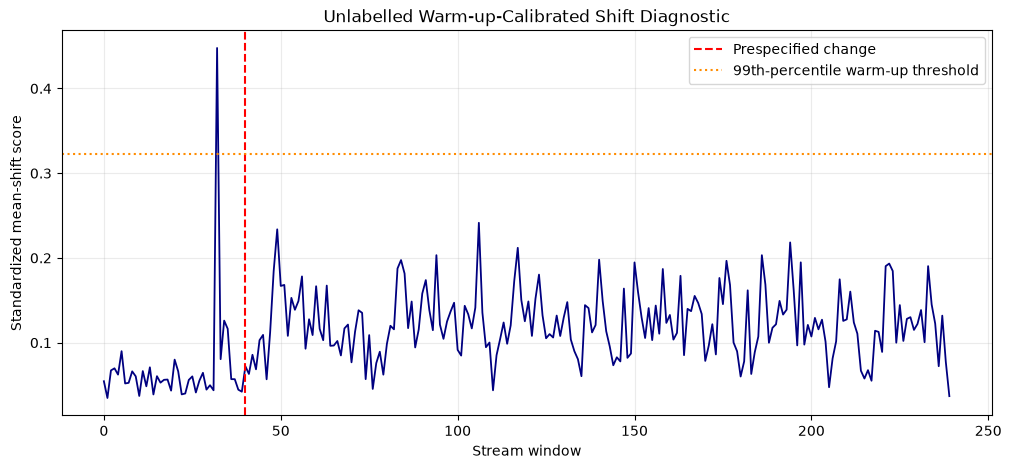

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(
    score_frame["window"],
    score_frame["warmup_reference_score"],
    color="navy",
    linewidth=1.3,
)

plt.axvline(
    change_window,
    color="red",
    linestyle="--",
    label="Prespecified change",
)

threshold_99 = float(pre_scores.quantile(0.99))

plt.axhline(
    threshold_99,
    color="darkorange",
    linestyle=":",
    label="99th-percentile warm-up threshold",
)

plt.xlabel("Stream window")
plt.ylabel("Standardized mean-shift score")
plt.title("Unlabelled Warm-up-Calibrated Shift Diagnostic")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [20]:
# 1. Identify the unusual pre-change windows

In [21]:
top_prechange = (
    score_frame[
        score_frame["phase"] == "pre_change"
    ]
    .nlargest(6, "warmup_reference_score")
)

display(top_prechange)

outlier_records = []

for _, row in top_prechange.iterrows():
    window_index = int(row["window"])
    start = window_index * window_size
    stop = min(start + window_size, len(target_bundle.labels))

    window_labels = target_bundle.labels.iloc[start:stop]
    window_features = target_bundle.features.iloc[start:stop]

    class_counts = window_labels.value_counts().to_dict()

    numeric_matrix = window_features.to_numpy(dtype=float)

    missing_values = int(np.isnan(numeric_matrix).sum())
    infinite_values = int(np.isinf(numeric_matrix).sum())

    times = pd.to_numeric(
        target_bundle.time.iloc[start:stop],
        errors="coerce",
    )

    outlier_records.append({
        "window": window_index,
        "score": row["warmup_reference_score"],
        "benign": class_counts.get("Benign", 0),
        "Exploits": class_counts.get("Exploits", 0),
        "Fuzzers": class_counts.get("Fuzzers", 0),
        "Generic": class_counts.get("Generic", 0),
        "Reconnaissance": class_counts.get("Reconnaissance", 0),
        "DoS": class_counts.get("DoS", 0),
        "missing_values": missing_values,
        "infinite_values": infinite_values,
        "first_time": pd.to_datetime(
            times.min(),
            unit="ms",
            errors="coerce",
        ),
        "last_time": pd.to_datetime(
            times.max(),
            unit="ms",
            errors="coerce",
        ),
    })

display(pd.DataFrame(outlier_records))

,window,warmup_reference_score,phase
32,32,0.447768,pre_change
34,34,0.126032,pre_change
35,35,0.116383,pre_change
5,5,0.089985,pre_change
33,33,0.080557,pre_change
20,20,0.079995,pre_change


,window,score,benign,Exploits,Fuzzers,Generic,Reconnaissance,DoS,missing_values,infinite_values,first_time,last_time
0,32,0.447768,485,3,8,0,3,1,10,26,2015-01-23 00:24:28.783,2015-02-18 00:39:20.335
1,34,0.126032,447,13,20,1,5,14,4,20,2015-02-18 00:42:29.831,2015-02-18 00:45:59.632
2,35,0.116383,448,16,21,1,10,4,2,22,2015-02-18 00:45:59.685,2015-02-18 00:49:18.799
3,5,0.089985,500,0,0,0,0,0,0,14,2015-01-22 22:42:47.471,2015-01-22 22:47:22.883
4,33,0.080557,465,15,7,4,6,3,4,20,2015-02-18 00:39:20.435,2015-02-18 00:42:29.831
5,20,0.079995,500,0,0,0,0,0,0,10,2015-01-22 23:41:11.832,2015-01-22 23:45:15.923


In [22]:
# 2. Compare robust calibration thresholds. This uses only the pre-change scores to construct thresholds.

In [23]:
pre_median = float(pre_scores.median())

mad = float(
    np.median(
        np.abs(pre_scores.to_numpy() - pre_median)
    )
)

robust_scale = 1.4826 * mad

robust_results = []

for multiplier in [3, 4, 5, 6]:
    threshold = pre_median + multiplier * robust_scale

    pre_false = int((pre_scores > threshold).sum())

    post_positions = np.flatnonzero(
        post_scores.to_numpy() > threshold
    )

    robust_results.append({
        "MAD_multiplier": multiplier,
        "threshold": threshold,
        "pre_change_false_triggers": pre_false,
        "post_windows_above_threshold": int(
            (post_scores > threshold).sum()
        ),
        "first_post_change_trigger_delay": (
            int(post_positions[0])
            if len(post_positions)
            else None
        ),
    })

display(pd.DataFrame(robust_results))

print("Pre-change median:", pre_median)
print("Raw MAD:", mad)
print("Scaled MAD:", robust_scale)

,MAD_multiplier,threshold,pre_change_false_triggers,post_windows_above_threshold,first_post_change_trigger_delay
0,3,0.103298,3,135,5
1,4,0.118951,2,100,8
2,5,0.134604,1,69,8
3,6,0.150257,1,42,8


Pre-change median: 0.0563400396819263
Raw MAD: 0.010557652341038365
Scaled MAD: 0.01565277536082348


In [24]:
# Create a session-aligned target stream

# This may take several minutes because it reloads and sorts the 0.538 GB dataset.

In [25]:
import gc
import numpy as np
import pandas as pd
import yaml

dataset_file = (
    PROJECT
    / "data"
    / "raw"
    / "NF-UNSW-NB15-v3.csv"
)

print("Loading dataset...")
full = pd.read_csv(dataset_file, low_memory=False)

full["FLOW_START_MILLISECONDS"] = pd.to_numeric(
    full["FLOW_START_MILLISECONDS"],
    errors="raise",
)

full["FLOW_END_MILLISECONDS"] = pd.to_numeric(
    full["FLOW_END_MILLISECONDS"],
    errors="coerce",
)

full["_original_row"] = np.arange(len(full))

print("Sorting chronologically...")
full = full.sort_values(
    [
        "FLOW_START_MILLISECONDS",
        "FLOW_END_MILLISECONDS",
        "_original_row",
    ],
    kind="mergesort",
).reset_index(drop=True)

# Identify the largest temporal gaps
time_differences = full["FLOW_START_MILLISECONDS"].diff()

largest_gap_indices = time_differences.nlargest(10).index

gap_records = []

for row_index in largest_gap_indices:
    previous_time = full.loc[
        row_index - 1,
        "FLOW_START_MILLISECONDS",
    ]

    current_time = full.loc[
        row_index,
        "FLOW_START_MILLISECONDS",
    ]

    gap_records.append({
        "current_row": int(row_index),
        "previous_time": pd.to_datetime(previous_time, unit="ms"),
        "current_time": pd.to_datetime(current_time, unit="ms"),
        "gap_hours": (current_time - previous_time) / 3_600_000,
    })

gap_table = pd.DataFrame(gap_records)

print("Largest timestamp gaps:")
display(gap_table)

Loading dataset...
Sorting chronologically...
Largest timestamp gaps:


,current_row,previous_time,current_time,gap_hours
0,1135352,2015-01-23 00:25:23.759,2015-02-18 00:23:27.658,623.967750
1,691295,2015-01-22 19:21:02.435,2015-01-22 19:35:20.845,0.238447
2,1135624,2015-02-18 00:27:51.323,2015-02-18 00:30:01.335,0.036114
3,1135633,2015-02-18 00:34:21.358,2015-02-18 00:36:31.369,0.036114
4,1135627,2015-02-18 00:30:33.371,2015-02-18 00:32:11.346,0.027215
5,1135621,2015-02-18 00:26:06.298,2015-02-18 00:27:33.798,0.024306
6,1135629,2015-02-18 00:32:11.346,2015-02-18 00:33:33.849,0.022918
7,1135636,2015-02-18 00:36:33.322,2015-02-18 00:37:40.070,0.018541
8,2007954,2015-02-18 09:05:53.857,2015-02-18 09:06:54.687,0.016897
9,155201,2015-01-22 13:24:57.855,2015-01-22 13:25:57.668,0.016615


In [26]:
# Select and verify the largest gap:

In [27]:
session_change_row = int(time_differences.idxmax())

previous_timestamp = full.loc[
    session_change_row - 1,
    "FLOW_START_MILLISECONDS",
]

new_session_timestamp = full.loc[
    session_change_row,
    "FLOW_START_MILLISECONDS",
]

largest_gap_hours = (
    new_session_timestamp - previous_timestamp
) / 3_600_000

print("Session-change row:", session_change_row)
print(
    "Previous session:",
    pd.to_datetime(previous_timestamp, unit="ms"),
)
print(
    "New session:",
    pd.to_datetime(new_session_timestamp, unit="ms"),
)
print("Gap in hours:", largest_gap_hours)

assert largest_gap_hours > 24, (
    "Largest gap is less than 24 hours; inspect the table manually."
)

Session-change row: 1135352
Previous session: 2015-01-23 00:25:23.759000
New session: 2015-02-18 00:23:27.658000
Gap in hours: 623.9677497222223


In [28]:
# Construct a clean target with:

# 20,000 flows before the session gap
# 100,000 flows after the session gap
# Exact change at row 20,000/window 40

In [29]:
SUPPORTED_CLASSES = [
    "Benign",
    "DoS",
    "Exploits",
    "Fuzzers",
    "Generic",
    "Reconnaissance",
]

number_of_rows = len(full)
source_cut = int(np.ceil(0.40 * number_of_rows))

assert source_cut < session_change_row, (
    "Historical source boundary occurs after the session transition."
)

warmup_pool = full.iloc[
    source_cut:session_change_row
].copy()

postchange_pool = full.iloc[
    session_change_row:
].copy()

warmup_pool = warmup_pool[
    warmup_pool["Attack"].isin(SUPPORTED_CLASSES)
].copy()

postchange_pool = postchange_pool[
    postchange_pool["Attack"].isin(SUPPORTED_CLASSES)
].copy()

print("Warm-up pool class distribution:")
display(warmup_pool["Attack"].value_counts().to_frame("Count"))

print("Post-change pool class distribution:")
display(postchange_pool["Attack"].value_counts().to_frame("Count"))

assert len(warmup_pool) >= 20_000
assert len(postchange_pool) >= 100_000

target_warmup = warmup_pool.sample(
    n=20_000,
    random_state=31,
)

target_postchange = postchange_pool.sample(
    n=100_000,
    random_state=32,
)

target_aligned = pd.concat(
    [target_warmup, target_postchange],
    ignore_index=True,
)

target_aligned = target_aligned.sort_values(
    ["FLOW_START_MILLISECONDS", "_original_row"],
    kind="mergesort",
).reset_index(drop=True)

# Verify that the boundary is a real temporal discontinuity
last_warmup_time = target_aligned.loc[
    19_999,
    "FLOW_START_MILLISECONDS",
]

first_postchange_time = target_aligned.loc[
    20_000,
    "FLOW_START_MILLISECONDS",
]

aligned_gap_hours = (
    first_postchange_time - last_warmup_time
) / 3_600_000

print("Aligned warm-up end:",
      pd.to_datetime(last_warmup_time, unit="ms"))

print("Aligned post-change start:",
      pd.to_datetime(first_postchange_time, unit="ms"))

print("Aligned gap hours:", aligned_gap_hours)

assert aligned_gap_hours > 24

target_aligned = target_aligned.drop(
    columns="_original_row"
)

aligned_target_path = (
    PROJECT
    / "data"
    / "processed"
    / "NF-UNSW-NB15-v3-target-session-aligned-pilot.csv"
)

target_aligned.to_csv(
    aligned_target_path,
    index=False,
)

print("Saved:", aligned_target_path)
print("Rows:", len(target_aligned))

Warm-up pool class distribution:


,Count
Attack,
Benign,189182


Post-change pool class distribution:


,Count
Attack,
Benign,1119841
Exploits,37126
Fuzzers,27770
Generic,17246
Reconnaissance,14919
DoS,5356


Aligned warm-up end: 2015-01-23 00:25:23.557000
Aligned post-change start: 2015-02-18 00:23:28.627000
Aligned gap hours: 623.968075
Saved: C:\Users\ASUS\raids-nids\data\processed\NF-UNSW-NB15-v3-target-session-aligned-pilot.csv
Rows: 120000


In [30]:
# Create its dataset configuration

In [31]:
aligned_target_config = {
    "name": "NF-UNSW-NB15-v3-Future-Session-Aligned-Pilot",
    "path": (
        "data/processed/"
        "NF-UNSW-NB15-v3-target-session-aligned-pilot.csv"
    ),
    "label_column": "Attack",
    "extra_label_columns": ["Label"],
    "time_column": "FLOW_START_MILLISECONDS",
    "drop_columns": [
        "FLOW_END_MILLISECONDS",
        "IPV4_SRC_ADDR",
        "IPV4_DST_ADDR",
    ],
    "auto_drop_identifiers": True,
    "sampling": {
        "max_rows": None,
    },
}

aligned_target_config_path = (
    PROJECT
    / "configs"
    / "datasets"
    / "nf_unsw_nb15_v3_target_session_aligned_pilot.yaml"
)

with aligned_target_config_path.open(
    "w",
    encoding="utf-8",
) as file:
    yaml.safe_dump(
        aligned_target_config,
        file,
        sort_keys=False,
    )

print("Created:", aligned_target_config_path)

del full, warmup_pool, postchange_pool
gc.collect()

Created: C:\Users\ASUS\raids-nids\configs\datasets\nf_unsw_nb15_v3_target_session_aligned_pilot.yaml


0

In [ ]:
# 1. Verify the saved pilot

In [32]:
from pathlib import Path
import os
import pandas as pd

PROJECT = Path(r"C:\Users\ASUS\raids-nids")
os.chdir(PROJECT)

TARGET_CSV = (
    PROJECT
    / "data"
    / "processed"
    / "NF-UNSW-NB15-v3-target-session-aligned-pilot.csv"
)

BOUNDARY_ROW = 20_000
WINDOW_SIZE = 500
SUPPORTED = {
    "Benign",
    "DoS",
    "Exploits",
    "Fuzzers",
    "Generic",
    "Reconnaissance",
}

metadata = pd.read_csv(
    TARGET_CSV,
    usecols=["FLOW_START_MILLISECONDS", "Attack"]
)

raw_time = metadata["FLOW_START_MILLISECONDS"]
numeric_time = pd.to_numeric(raw_time, errors="coerce")

if numeric_time.notna().all():
    timestamps = pd.to_datetime(
        numeric_time,
        unit="ms",
        errors="raise"
    )
else:
    timestamps = pd.to_datetime(raw_time, errors="raise")

boundary_gap_hours = (
    timestamps.iloc[BOUNDARY_ROW]
    - timestamps.iloc[BOUNDARY_ROW - 1]
).total_seconds() / 3600

warmup_labels = metadata.iloc[:BOUNDARY_ROW]["Attack"]
post_labels = metadata.iloc[BOUNDARY_ROW:]["Attack"]

assert len(metadata) == 120_000
assert timestamps.is_monotonic_increasing
assert BOUNDARY_ROW % WINDOW_SIZE == 0
assert BOUNDARY_ROW // WINDOW_SIZE == 40
assert boundary_gap_hours > 24
assert set(warmup_labels) == {"Benign"}
assert set(post_labels) == SUPPORTED

def distribution(labels):
    counts = labels.value_counts()
    return pd.DataFrame({
        "count": counts,
        "percent": (100 * counts / counts.sum()).round(4)
    })

phase_distribution = pd.concat(
    {
        "warmup": distribution(warmup_labels),
        "post_change": distribution(post_labels),
    },
    names=["phase", "Attack"]
)

print("Rows:", len(metadata))
print("Windows:", len(metadata) // WINDOW_SIZE)
print("Declared change window:", BOUNDARY_ROW // WINDOW_SIZE)
print("Boundary gap hours:", boundary_gap_hours)
display(phase_distribution)

Rows: 120000
Windows: 240
Declared change window: 40
Boundary gap hours: 623.968075


count  percent
phase       Attack                        
warmup      Benign          20000  100.000
post_change Benign          91612   91.612
            Exploits         3015    3.015
            Fuzzers          2319    2.319
            Generic          1423    1.423
            Reconnaissance   1219    1.219
            DoS               412    0.412

In [33]:
# 2. Create session-aligned static configurations

# This clones the exact configurations used for your previous three baselines, preserving their hyperparameters.

In [35]:
import copy
from pathlib import Path

from raids_nids.config import load_yaml, dump_yaml

NEW_RUN_NAME = "E02_E05_UNSW_session_aligned_pilot_v012"

NEW_TARGET_CONFIG = (
    "configs/datasets/"
    "nf_unsw_nb15_v3_target_session_aligned_pilot.yaml"
)

METHOD_FILES = {
    "prototype_static_closed":
        "unsw_session_aligned_prototype_static_v012.yaml",
    "logistic_closed":
        "unsw_session_aligned_logistic_static_v012.yaml",
    "random_forest_closed":
        "unsw_session_aligned_random_forest_static_v012.yaml",
}

runs_root = PROJECT / "results" / "runs"
experiment_root = PROJECT / "configs" / "experiments"
experiment_root.mkdir(parents=True, exist_ok=True)

# Find all previous resolved configurations by method name.
candidates = {method: [] for method in METHOD_FILES}

for resolved_path in runs_root.rglob("resolved_config.yaml"):
    try:
        candidate = load_yaml(resolved_path)
    except Exception:
        continue

    method_name = candidate.get("method", {}).get("name")

    if method_name not in METHOD_FILES:
        continue

    source_text = str(candidate.get("source_dataset", "")).lower()
    target_text = str(candidate.get("target_dataset", "")).lower()
    adaptation_enabled = bool(
        candidate.get("adaptation", {}).get("enabled", False)
    )

    # Retain only static NF-UNSW-NB15-v3 experiments.
    if (
        "nf_unsw_nb15_v3" in source_text
        and "nf_unsw_nb15_v3" in target_text
        and not adaptation_enabled
    ):
        candidates[method_name].append(
            (resolved_path, candidate)
        )

# Show everything that was found.
candidate_rows = []

for method_name, items in candidates.items():
    for path, config in items:
        candidate_rows.append({
            "method": method_name,
            "run_name": config.get("name"),
            "target_config": config.get("target_dataset"),
            "resolved_config": str(path),
        })

candidate_table = pd.DataFrame(candidate_rows)

if len(candidate_table):
    display(
        candidate_table.sort_values(
            ["method", "run_name"]
        )
    )

missing = [
    method
    for method, items in candidates.items()
    if not items
]

if missing:
    raise FileNotFoundError(
        "No static NF-UNSW resolved configuration was found for: "
        f"{missing}"
    )

# Prefer the old non-session-aligned pilot, then the newest candidate.
def candidate_rank(item):
    path, config = item
    target = str(config.get("target_dataset", "")).lower()
    run_name = str(config.get("name", "")).lower()

    is_old_target = (
        "target_pilot" in target
        and "session_aligned" not in target
    )

    is_temporal_pilot = (
        "temporal" in run_name
        and "session_aligned" not in run_name
    )

    return (
        int(is_old_target),
        int(is_temporal_pilot),
        path.stat().st_mtime,
    )

selected_configs = {
    method: max(items, key=candidate_rank)
    for method, items in candidates.items()
}

aligned_config_paths = {}

for method_name, filename in METHOD_FILES.items():
    source_path, old_config = selected_configs[method_name]
    config = copy.deepcopy(old_config)

    config["name"] = NEW_RUN_NAME
    config["seed"] = 11
    config["target_dataset"] = NEW_TARGET_CONFIG
    config["output_root"] = "results/runs"

    config.setdefault("scenario", {})
    config["scenario"]["name"] = (
        "supported_6class_capture_session_and_prevalence_shift"
    )
    config["scenario"]["holdout_labels"] = []

    config.setdefault("stream", {})
    config["stream"]["mode"] = "chronological"
    config["stream"]["window_size"] = 500
    config["stream"]["true_change_window"] = 40
    config["stream"].pop("known_prefix_fraction", None)

    config.setdefault("method", {})
    config["method"]["name"] = method_name
    config["method"]["open_set"] = False

    config.setdefault("adaptation", {})
    config["adaptation"]["enabled"] = False
    config["adaptation"]["label_budget_fraction"] = 0.0

    output_path = experiment_root / filename
    dump_yaml(config, output_path)
    aligned_config_paths[method_name] = output_path

    print(f"\n{method_name}")
    print("Selected previous configuration:")
    print(source_path)
    print("Created aligned configuration:")
    print(output_path)

print("\nAll three configurations created successfully.")

,method,run_name,target_config,resolved_config
2,logistic_closed,E02_E05_UNSW_logistic_v012,configs/datasets/nf_unsw_nb15_v3_target_pilot....,C:\Users\ASUS\raids-nids\results\runs\E02_E05_...
1,prototype_static_closed,E02_E05_UNSW_temporal_pilot,configs/datasets/nf_unsw_nb15_v3_target_pilot....,C:\Users\ASUS\raids-nids\results\runs\E02_E05_...
0,prototype_static_closed,E02_E05_UNSW_temporal_pilot_v012,configs/datasets/nf_unsw_nb15_v3_target_pilot....,C:\Users\ASUS\raids-nids\results\runs\E02_E05_...
3,random_forest_closed,E02_E05_UNSW_random_forest_v012,configs/datasets/nf_unsw_nb15_v3_target_pilot....,C:\Users\ASUS\raids-nids\results\runs\E02_E05_...



prototype_static_closed
Selected previous configuration:
C:\Users\ASUS\raids-nids\results\runs\E02_E05_UNSW_temporal_pilot_v012__NF-UNSW-NB15-v3-Historical-Pilot-to-NF-UNSW-NB15-v3-Future-Pilot__supported_6class_temporal_shift__prototype_static_closed__seed11\resolved_config.yaml
Created aligned configuration:
C:\Users\ASUS\raids-nids\configs\experiments\unsw_session_aligned_prototype_static_v012.yaml

logistic_closed
Selected previous configuration:
C:\Users\ASUS\raids-nids\results\runs\E02_E05_UNSW_logistic_v012__NF-UNSW-NB15-v3-Historical-Pilot-to-NF-UNSW-NB15-v3-Future-Pilot__supported_6class_temporal_shift__logistic_closed__seed11\resolved_config.yaml
Created aligned configuration:
C:\Users\ASUS\raids-nids\configs\experiments\unsw_session_aligned_logistic_static_v012.yaml

random_forest_closed
Selected previous configuration:
C:\Users\ASUS\raids-nids\results\runs\E02_E05_UNSW_random_forest_v012__NF-UNSW-NB15-v3-Historical-Pilot-to-NF-UNSW-NB15-v3-Future-Pilot__supported_6class_te

In [36]:
# 3. Run the three corrected baselines

In [37]:
import pandas as pd

from raids_nids.runner import run_experiment

aligned_summaries = []

for method_name, config_path in aligned_config_paths.items():
    print(f"\nRunning {method_name}...")
    summary = run_experiment(config_path)
    aligned_summaries.append(summary)
    print("Completed.")

for summary in aligned_summaries:
    assert summary["target_rows"] == 120_000
    assert summary["window_count"] == 240
    assert summary["true_change_window"] == 40
    assert summary["novel_target_classes"] == []
    assert summary["labels_queried"] == 0
    assert summary["integrity_checks"]["label_budget_respected"]
    assert summary["integrity_checks"]["predictions_scored_before_updates"]
    assert summary["integrity_checks"]["preprocessing_fit_on_source_only"]

aligned_results = pd.DataFrame(aligned_summaries)

result_columns = [
    "method",
    "source_reference_macro_f1",
    "global_known_macro_f1",
    "global_known_balanced_accuracy",
    "global_known_mcc",
    "mean_known_macro_f1",
    "pre_change_reference",
    "initial_degradation",
    "primary_normalized_recovery_area",
    "recovery_time_windows",
    "fit_seconds",
    "prediction_seconds",
]

display(
    aligned_results[result_columns]
    .sort_values("global_known_macro_f1", ascending=False)
)

integrity_table = pd.DataFrame([
    {
        "method": row["method"],
        **row["integrity_checks"]
    }
    for row in aligned_summaries
])

display(integrity_table)


Running prototype_static_closed...
Completed.

Running logistic_closed...


C:\Users\ASUS\anaconda3\envs\raids-nids\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Completed.

Running random_forest_closed...
Completed.


,method,source_reference_macro_f1,global_known_macro_f1,global_known_balanced_accuracy,global_known_mcc,mean_known_macro_f1,pre_change_reference,initial_degradation,primary_normalized_recovery_area,recovery_time_windows,fit_seconds,prediction_seconds
2,random_forest_closed,0.743619,0.725356,0.711297,0.863482,0.782147,1.000000,0.227824,0.738576,4,6.920047,36.786131
1,logistic_closed,0.548276,0.533897,0.604073,0.685427,0.626118,0.999825,0.538658,0.551472,4,37.046280,3.743798
0,prototype_static_closed,0.340275,0.314826,0.362588,0.466123,0.457173,0.989192,0.525560,0.354572,4,1.126076,3.167358


,method,initial_model_saw_novel_target_class_names,label_budget_respected,predictions_scored_before_updates,preprocessing_fit_on_source_only
0,prototype_static_closed,False,True,True,True
1,logistic_closed,False,True,True,True
2,random_forest_closed,False,True,True,True


In [38]:
# 1. Logistic convergence rerun

In [39]:
import copy
import warnings
import joblib
import numpy as np
import pandas as pd

from sklearn.exceptions import ConvergenceWarning
from raids_nids.config import load_yaml, dump_yaml
from raids_nids.runner import run_experiment

base_logistic_config = (
    PROJECT
    / "configs"
    / "experiments"
    / "unsw_session_aligned_logistic_static_v012.yaml"
)

converged_config_path = (
    PROJECT
    / "configs"
    / "experiments"
    / "unsw_session_aligned_logistic_5000_v012.yaml"
)

logistic_config = copy.deepcopy(
    load_yaml(base_logistic_config)
)

logistic_config["name"] = (
    "E02_E05_UNSW_session_aligned_logistic_5000_v012"
)

logistic_config.setdefault("method", {})
logistic_config["method"]["name"] = "logistic_closed"
logistic_config["method"]["type"] = "logistic"
logistic_config["method"]["open_set"] = False

logistic_config["method"].setdefault("parameters", {})
logistic_config["method"]["parameters"]["max_iter"] = 5000

dump_yaml(logistic_config, converged_config_path)

with warnings.catch_warnings(record=True) as recorded_warnings:
    warnings.simplefilter("always", ConvergenceWarning)

    logistic_5000_summary = run_experiment(
        converged_config_path
    )

convergence_warnings = [
    warning
    for warning in recorded_warnings
    if issubclass(warning.category, ConvergenceWarning)
]

print("Convergence warnings:", len(convergence_warnings))

Convergence warnings: 0


In [40]:
# Locate the saved model and verify its actual iteration count:

In [41]:
matching_runs = []

for resolved_path in (
    PROJECT / "results" / "runs"
).rglob("resolved_config.yaml"):

    config = load_yaml(resolved_path)

    if (
        config.get("name")
        == "E02_E05_UNSW_session_aligned_logistic_5000_v012"
        and config.get("method", {}).get("name")
        == "logistic_closed"
    ):
        matching_runs.append(resolved_path.parent)

if not matching_runs:
    raise FileNotFoundError(
        "Could not find the 5000-iteration logistic run."
    )

logistic_run_dir = max(
    matching_runs,
    key=lambda path: path.stat().st_mtime
)

logistic_model = joblib.load(
    logistic_run_dir / "model.joblib"
)

iterations_used = logistic_model.estimator.n_iter_
maximum_iterations = logistic_model.estimator.max_iter

print("Iterations used:", iterations_used)
print("Maximum allowed:", maximum_iterations)
print(
    "Converged:",
    len(convergence_warnings) == 0
    and np.all(iterations_used < maximum_iterations)
)

display(pd.DataFrame([logistic_5000_summary])[[
    "method",
    "source_reference_macro_f1",
    "global_known_macro_f1",
    "global_known_balanced_accuracy",
    "global_known_mcc",
    "mean_known_macro_f1",
    "pre_change_reference",
    "initial_degradation",
    "primary_normalized_recovery_area",
    "recovery_time_windows",
    "fit_seconds",
    "prediction_seconds",
]])

Iterations used: [1334]
Maximum allowed: 5000
Converged: True


,method,source_reference_macro_f1,global_known_macro_f1,global_known_balanced_accuracy,global_known_mcc,mean_known_macro_f1,pre_change_reference,initial_degradation,primary_normalized_recovery_area,recovery_time_windows,fit_seconds,prediction_seconds
0,logistic_closed,0.548714,0.534297,0.604885,0.685359,0.626315,0.999825,0.54136,0.551707,4,50.755142,4.801183


In [ ]:
# 2. Investigate the apparent four-window recovery

# This checks whether windows 44–45 are simply benign-dominated.

In [42]:
TARGET_CSV = (
    PROJECT
    / "data"
    / "processed"
    / "NF-UNSW-NB15-v3-target-session-aligned-pilot.csv"
)

WINDOW_SIZE = 500
CHANGE_WINDOW = 40

target_labels = pd.read_csv(
    TARGET_CSV,
    usecols=["Attack"]
)

target_labels["window"] = (
    np.arange(len(target_labels)) // WINDOW_SIZE
)

class_counts = pd.crosstab(
    target_labels["window"],
    target_labels["Attack"]
)

for label in [
    "Benign",
    "DoS",
    "Exploits",
    "Fuzzers",
    "Generic",
    "Reconnaissance",
]:
    if label not in class_counts:
        class_counts[label] = 0

class_counts["attack_rows"] = (
    class_counts.drop(columns=["Benign"]).sum(axis=1)
)

class_counts["attack_percent"] = (
    100 * class_counts["attack_rows"] / WINDOW_SIZE
)

class_counts["classes_present"] = (
    class_counts[
        [
            "Benign",
            "DoS",
            "Exploits",
            "Fuzzers",
            "Generic",
            "Reconnaissance",
        ]
    ].gt(0).sum(axis=1)
)

def find_run_directory(run_name, method_name):
    matches = []

    for resolved_path in (
        PROJECT / "results" / "runs"
    ).rglob("resolved_config.yaml"):

        config = load_yaml(resolved_path)

        if (
            config.get("name") == run_name
            and config.get("method", {}).get("name")
            == method_name
        ):
            matches.append(resolved_path.parent)

    if not matches:
        raise FileNotFoundError(
            f"No run found for {method_name}"
        )

    return max(
        matches,
        key=lambda path: path.stat().st_mtime
    )

trace = class_counts.reset_index()

for method_name in [
    "prototype_static_closed",
    "logistic_closed",
    "random_forest_closed",
]:
    run_dir = find_run_directory(
        "E02_E05_UNSW_session_aligned_pilot_v012",
        method_name
    )

    windows = pd.read_csv(run_dir / "windows.csv")

    trace = trace.merge(
        windows[["window", "known_macro_f1"]].rename(
            columns={
                "known_macro_f1": f"{method_name}_macro_f1"
            }
        ),
        on="window",
        how="left",
    )

display(
    trace.loc[
        trace["window"].between(38, 52),
        [
            "window",
            "Benign",
            "DoS",
            "Exploits",
            "Fuzzers",
            "Generic",
            "Reconnaissance",
            "attack_percent",
            "classes_present",
            "prototype_static_closed_macro_f1",
            "logistic_closed_macro_f1",
            "random_forest_closed_macro_f1",
        ],
    ]
)

,window,Benign,DoS,Exploits,Fuzzers,Generic,Reconnaissance,attack_percent,classes_present,prototype_static_closed_macro_f1,logistic_closed_macro_f1,random_forest_closed_macro_f1
38,38,500,0,0,0,0,0,0.0,1,0.998999,1.000000,1.000000
39,39,500,0,0,0,0,0,0.0,1,0.987854,1.000000,1.000000
40,40,475,1,8,11,1,4,5.0,6,0.463632,0.461167,0.772176
41,41,462,7,15,8,5,3,7.6,6,0.263887,0.455634,0.642806
42,42,447,13,8,27,0,5,10.6,5,0.415874,0.591889,0.724062
43,43,472,1,4,19,0,4,5.6,5,0.356080,0.482495,0.495610
44,44,500,0,0,0,0,0,0.0,1,0.994975,1.000000,1.000000
45,45,500,0,0,0,0,0,0.0,1,0.982706,0.998999,0.998999
46,46,500,0,0,0,0,0,0.0,1,0.986829,1.000000,1.000000
47,47,494,2,4,0,0,0,1.2,3,0.326489,0.333333,0.851852


In [43]:
# Next, test recovery using 5,000-row evaluation blocks and three-block persistence. This reduces class-support instability.

# Create 5,000-row evaluation configurations

In [44]:
import copy
from raids_nids.config import load_yaml, dump_yaml

BASE_CONFIGS = {
    "prototype_static_closed": (
        PROJECT / "configs" / "experiments"
        / "unsw_session_aligned_prototype_static_v012.yaml"
    ),
    "logistic_closed": (
        PROJECT / "configs" / "experiments"
        / "unsw_session_aligned_logistic_5000_v012.yaml"
    ),
    "random_forest_closed": (
        PROJECT / "configs" / "experiments"
        / "unsw_session_aligned_random_forest_static_v012.yaml"
    ),
}

OUTPUT_FILES = {
    "prototype_static_closed":
        "unsw_session_aligned_prototype_eval5000_v012.yaml",
    "logistic_closed":
        "unsw_session_aligned_logistic_eval5000_v012.yaml",
    "random_forest_closed":
        "unsw_session_aligned_random_forest_eval5000_v012.yaml",
}

EVENT_ROW = 20_000
EVALUATION_BLOCK_SIZE = 5_000

assert EVENT_ROW % EVALUATION_BLOCK_SIZE == 0
CHANGE_BLOCK = EVENT_ROW // EVALUATION_BLOCK_SIZE

eval5000_config_paths = {}

for method_name, base_path in BASE_CONFIGS.items():
    config = copy.deepcopy(load_yaml(base_path))

    config["name"] = (
        "E02_E05_UNSW_session_aligned_eval5000_v012"
    )

    config["scenario"]["name"] = (
        "supported_6class_capture_session_and_prevalence_shift"
    )

    config["stream"]["mode"] = "chronological"
    config["stream"]["window_size"] = EVALUATION_BLOCK_SIZE
    config["stream"]["true_change_window"] = CHANGE_BLOCK

    config.setdefault("metrics", {})
    config["metrics"]["recovery_fraction"] = 0.95

    # Three consecutive blocks = 15,000 observations.
    config["metrics"]["recovery_patience_windows"] = 3

    config["method"]["open_set"] = False
    config["adaptation"]["enabled"] = False
    config["adaptation"]["label_budget_fraction"] = 0.0

    if method_name == "logistic_closed":
        config["method"].setdefault("parameters", {})
        config["method"]["parameters"]["max_iter"] = 5000

    output_path = (
        PROJECT
        / "configs"
        / "experiments"
        / OUTPUT_FILES[method_name]
    )

    dump_yaml(config, output_path)
    eval5000_config_paths[method_name] = output_path

    print("Created:", output_path)

print("Change block:", CHANGE_BLOCK)
print("Total evaluation blocks:", 120_000 // EVALUATION_BLOCK_SIZE)

Created: C:\Users\ASUS\raids-nids\configs\experiments\unsw_session_aligned_prototype_eval5000_v012.yaml
Created: C:\Users\ASUS\raids-nids\configs\experiments\unsw_session_aligned_logistic_eval5000_v012.yaml
Created: C:\Users\ASUS\raids-nids\configs\experiments\unsw_session_aligned_random_forest_eval5000_v012.yaml
Change block: 4
Total evaluation blocks: 24


In [ ]:
# Run the 5,000-row baselines

In [45]:
import warnings
import pandas as pd

from sklearn.exceptions import ConvergenceWarning
from raids_nids.runner import run_experiment

eval5000_summaries = []
convergence_warning_count = 0

for method_name, config_path in eval5000_config_paths.items():
    print(f"\nRunning {method_name}...")

    with warnings.catch_warnings(record=True) as captured:
        warnings.simplefilter("always", ConvergenceWarning)
        summary = run_experiment(config_path)

    convergence_warning_count += sum(
        issubclass(item.category, ConvergenceWarning)
        for item in captured
    )

    eval5000_summaries.append(summary)
    print("Completed.")

eval5000_results = pd.DataFrame(eval5000_summaries)

assert (eval5000_results["target_rows"] == 120_000).all()
assert (eval5000_results["window_count"] == 24).all()
assert (eval5000_results["true_change_window"] == 4).all()

print(
    "Total convergence warnings:",
    convergence_warning_count
)

display(
    eval5000_results[[
        "method",
        "source_reference_macro_f1",
        "global_known_macro_f1",
        "global_known_balanced_accuracy",
        "global_known_mcc",
        "mean_known_macro_f1",
        "pre_change_reference",
        "initial_degradation",
        "primary_normalized_recovery_area",
        "recovery_time_windows",
        "fit_seconds",
        "prediction_seconds",
    ]].sort_values(
        "global_known_macro_f1",
        ascending=False
    )
)


Running prototype_static_closed...
Completed.

Running logistic_closed...
Completed.

Running random_forest_closed...
Completed.
Total convergence warnings: 0


,method,source_reference_macro_f1,global_known_macro_f1,global_known_balanced_accuracy,global_known_mcc,mean_known_macro_f1,pre_change_reference,initial_degradation,primary_normalized_recovery_area,recovery_time_windows,fit_seconds,prediction_seconds
2,random_forest_closed,0.743619,0.725356,0.711297,0.863482,0.764654,1.000000,0.312351,0.717585,None,6.401859,4.894388
1,logistic_closed,0.548714,0.534297,0.604885,0.685359,0.601427,0.999825,0.524504,0.521838,None,51.872850,0.688732
0,prototype_static_closed,0.340275,0.314826,0.362588,0.466123,0.429856,0.989227,0.671080,0.321445,None,1.188787,0.743708


In [ ]:
# Verify class support in each 5,000-row block

In [46]:
target_labels = pd.read_csv(
    TARGET_CSV,
    usecols=["Attack"]
)

target_labels["evaluation_block"] = (
    np.arange(len(target_labels))
    // EVALUATION_BLOCK_SIZE
)

block_counts = pd.crosstab(
    target_labels["evaluation_block"],
    target_labels["Attack"]
)

supported_order = [
    "Benign",
    "DoS",
    "Exploits",
    "Fuzzers",
    "Generic",
    "Reconnaissance",
]

for label in supported_order:
    if label not in block_counts:
        block_counts[label] = 0

block_counts["attack_rows"] = (
    block_counts.drop(columns=["Benign"]).sum(axis=1)
)

block_counts["attack_percent"] = (
    100
    * block_counts["attack_rows"]
    / EVALUATION_BLOCK_SIZE
)

block_counts["classes_present"] = (
    block_counts[supported_order]
    .gt(0)
    .sum(axis=1)
)

display(
    block_counts.loc[
        2:10,
        supported_order
        + [
            "attack_rows",
            "attack_percent",
            "classes_present",
        ]
    ]
)

Attack,Benign,DoS,Exploits,Fuzzers,Generic,Reconnaissance,attack_rows,attack_percent,classes_present
evaluation_block,,,,,,,,,
2,5000,0,0,0,0,0,0,0.00,1
3,5000,0,0,0,0,0,0,0.00,1
4,4796,25,69,78,8,24,204,4.08,6
5,4563,12,150,108,87,80,437,8.74,6
6,4472,20,160,141,147,60,528,10.56,6
7,4542,18,183,163,25,69,458,9.16,6
8,4663,12,134,111,34,46,337,6.74,6
9,4532,26,141,92,136,73,468,9.36,6
10,4579,23,150,131,61,56,421,8.42,6


In [1]:
from pathlib import Path
from datetime import datetime
from zipfile import ZipFile
import shutil
import subprocess
import sys

PROJECT = Path(r"C:\Users\ASUS\raids-nids")
PATCH = Path(
    r"C:\Users\ASUS\Downloads"
    r"\RAIDS_NIDS_v0.1.3_decoupled_evaluation_patch.zip"
)

assert PROJECT.exists(), PROJECT
assert PATCH.exists(), PATCH

backup_root = (
    PROJECT
    / "patch_backups"
    / datetime.now().strftime("before_v013_%Y%m%d_%H%M%S")
)

with ZipFile(PATCH) as archive:
    for member in archive.infolist():
        if member.is_dir():
            continue

        destination = PROJECT / member.filename

        if destination.exists():
            backup = backup_root / member.filename
            backup.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(destination, backup)

    archive.extractall(PROJECT)

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "--no-deps",
    "--editable",
    str(PROJECT),
])

print("Patch installed.")
print("Backup:", backup_root)
print("Now restart the Jupyter kernel.")

Patch installed.
Backup: C:\Users\ASUS\raids-nids\patch_backups\before_v013_20260717_193114
Now restart the Jupyter kernel.


In [1]:
# Restart the kernel, then run:

In [2]:
from pathlib import Path
import os
import raids_nids

PROJECT = Path(r"C:\Users\ASUS\raids-nids")
os.chdir(PROJECT)

print("Version:", raids_nids.__version__)
print("Imported from:", raids_nids.__file__)

assert raids_nids.__version__ == "0.1.3"

Version: 0.1.3
Imported from: C:\Users\ASUS\raids-nids\src\raids_nids\__init__.py


In [3]:
# Validate decoupled evaluation

In [4]:
import copy
import pandas as pd

from raids_nids.config import load_yaml, dump_yaml
from raids_nids.runner import run_experiment

base_path = (
    PROJECT
    / "configs"
    / "experiments"
    / "unsw_session_aligned_prototype_static_v012.yaml"
)

config = copy.deepcopy(load_yaml(base_path))

config["name"] = "E02_E05_UNSW_decoupled_static_check_v013"

config["stream"]["mode"] = "chronological"
config["stream"]["window_size"] = 500
config["stream"]["true_change_window"] = 40

config.setdefault("metrics", {})
config["metrics"].update({
    "evaluation_window_size": 5000,
    "recovery_fraction": 0.95,
    "recovery_patience_windows": 2,
    "recovery_patience_evaluation_blocks": 3,
    "normal_labels": ["Benign"],
    "minimum_evaluation_known_classes": 6,
    "minimum_evaluation_rows_per_known_class": 5,
    "minimum_evaluation_non_normal_rows": 100,
})

config["adaptation"]["enabled"] = False
config["adaptation"]["label_budget_fraction"] = 0.0

config_path = (
    PROJECT
    / "configs"
    / "experiments"
    / "unsw_decoupled_static_check_v013.yaml"
)

dump_yaml(config, config_path)

v013_summary = run_experiment(config_path)

display(pd.DataFrame([v013_summary])[[
    "method",
    "metric_contract_version",
    "stream_window_size",
    "window_count",
    "evaluation_window_size",
    "evaluation_window_count",
    "true_change_window",
    "true_change_evaluation_window",
    "global_known_macro_f1",
    "mean_known_macro_f1",
    "evaluation_mean_known_macro_f1",
    "stream_first_passage_recovery_time_windows",
    "eligible_post_evaluation_blocks",
    "primary_normalized_recovery_area",
    "recovery_time_evaluation_blocks",
    "recovery_time_windows",
]])

,method,metric_contract_version,stream_window_size,window_count,evaluation_window_size,evaluation_window_count,true_change_window,true_change_evaluation_window,global_known_macro_f1,mean_known_macro_f1,evaluation_mean_known_macro_f1,stream_first_passage_recovery_time_windows,eligible_post_evaluation_blocks,primary_normalized_recovery_area,recovery_time_evaluation_blocks,recovery_time_windows
0,prototype_static_closed,1.2-decoupled-support-aware-evaluation,500,240,5000,24,40,4,0.314826,0.457173,0.429856,4,20,0.321445,None,None


In [6]:
import joblib
import numpy as np
import pandas as pd

from raids_nids.config import load_yaml
from raids_nids.data import load_dataset

RUN_NAME = "E02_E05_UNSW_decoupled_static_check_v013"
METHOD_NAME = "prototype_static_closed"

runs_root = PROJECT / "results" / "runs"
matching_runs = []

for resolved_path in runs_root.rglob("resolved_config.yaml"):
    run_config = load_yaml(resolved_path)

    if (
        run_config.get("name") == RUN_NAME
        and run_config.get("method", {}).get("name")
        == METHOD_NAME
    ):
        matching_runs.append(
            (resolved_path.parent, run_config)
        )

if not matching_runs:
    raise FileNotFoundError(
        "Could not locate the v0.1.3 prototype run."
    )

run_dir, run_config = max(
    matching_runs,
    key=lambda item: item[0].stat().st_mtime
)

model = joblib.load(run_dir / "model.joblib")
target = load_dataset(run_config["target_dataset"])

assert target.time is not None

# Reproduce the runner's stable chronological ordering.
order_frame = pd.DataFrame({
    "__time__": np.asarray(target.time),
    "__row__": np.arange(len(target.features)),
})

ordered_indices = (
    order_frame
    .sort_values(["__time__", "__row__"], kind="stable")
    ["__row__"]
    .to_numpy()
)

ordered_x = (
    target.features
    .iloc[ordered_indices]
    .reset_index(drop=True)
)

print("Model:", run_dir / "model.joblib")
print("Target rows:", len(ordered_x))

Model: C:\Users\ASUS\raids-nids\results\runs\E02_E05_UNSW_decoupled_static_check_v013__NF-UNSW-NB15-v3-Historical-Pilot-to-NF-UNSW-NB15-v3-Future-Session-Aligned-Pilot__supported_6class_capture_session_and_prevalence_shift__prototype_static_closed__seed11\model.joblib
Target rows: 120000


In [7]:
# Calculate the unlabelled shift scores:

In [8]:
STREAM_WINDOW_SIZE = 500
CHANGE_WINDOW = 40

REFERENCE_START = 0
REFERENCE_STOP = 10

CALIBRATION_START = 10
CALIBRATION_STOP = 30

GUARD_START = 30
GUARD_STOP = 40

reference_x = ordered_x.iloc[
    REFERENCE_START * STREAM_WINDOW_SIZE:
    REFERENCE_STOP * STREAM_WINDOW_SIZE
]

reference_embedding = model.embed(reference_x)

reference_mean = reference_embedding.mean(axis=0)
reference_std = reference_embedding.std(axis=0) + 1e-6

shift_records = []

for window, start in enumerate(
    range(0, len(ordered_x), STREAM_WINDOW_SIZE)
):
    stop = min(
        start + STREAM_WINDOW_SIZE,
        len(ordered_x)
    )

    embedding = model.embed(
        ordered_x.iloc[start:stop]
    )

    standardized_mean = (
        embedding.mean(axis=0) - reference_mean
    ) / reference_std

    shift_score = float(
        np.linalg.norm(standardized_mean)
        / np.sqrt(len(standardized_mean))
    )

    if window < REFERENCE_STOP:
        phase = "reference"
    elif window < CALIBRATION_STOP:
        phase = "calibration"
    elif window < GUARD_STOP:
        phase = "guard"
    else:
        phase = "post_change"

    shift_records.append({
        "window": window,
        "shift_score": shift_score,
        "phase": phase,
    })

shift_scores = pd.DataFrame(shift_records)

display(
    shift_scores.groupby("phase")["shift_score"]
    .agg(["count", "mean", "std", "min", "median", "max"])
)

,count,mean,std,min,median,max
phase,,,,,,
calibration,20,0.068209,0.020247,0.038881,0.066584,0.130656
guard,10,0.072074,0.025256,0.035820,0.066528,0.110756
post_change,200,0.170673,0.059833,0.046437,0.167160,0.441357
reference,10,0.072746,0.023840,0.031453,0.074189,0.112379


In [9]:
# Calibrate using only windows 10–29:

In [10]:
calibration_scores = shift_scores.loc[
    shift_scores["phase"] == "calibration",
    "shift_score",
].to_numpy()

calibration_median = float(
    np.median(calibration_scores)
)

raw_mad = float(
    np.median(
        np.abs(calibration_scores - calibration_median)
    )
)

scaled_mad = 1.4826 * raw_mad

if scaled_mad <= 1e-12:
    raise RuntimeError(
        "Calibration MAD is effectively zero."
    )

print("Calibration median:", calibration_median)
print("Raw MAD:", raw_mad)
print("Scaled MAD:", scaled_mad)

Calibration median: 0.06658449237060762
Raw MAD: 0.010700847751783142
Scaled MAD: 0.015865076876793685


In [11]:
# Apply two-window persistence:

In [14]:
def persistent_triggers(
    values,
    threshold,
    starting_window,
    persistence=2,
    cooldown=3,
):
    triggers = []
    consecutive = 0
    last_trigger = -10**9

    for offset, value in enumerate(values):
        window = starting_window + offset

        if value >= threshold:
            consecutive += 1
        else:
            consecutive = 0

        if (
            consecutive >= persistence
            and window - last_trigger >= cooldown
        ):
            triggers.append(window)
            last_trigger = window
            consecutive = 0

    return triggers

In [15]:
# Select the threshold without examining post-change results:

In [16]:
guard_scores = shift_scores.loc[
    shift_scores["phase"] == "guard",
    "shift_score",
].to_numpy()

candidate_rows = []

for multiplier in [3, 4, 5, 6]:
    threshold = (
        calibration_median
        + multiplier * scaled_mad
    )

    guard_triggers = persistent_triggers(
        guard_scores,
        threshold,
        starting_window=GUARD_START,
        persistence=2,
        cooldown=3,
    )

    candidate_rows.append({
        "MAD_multiplier": multiplier,
        "threshold": threshold,
        "calibration_windows_above": int(
            np.sum(calibration_scores >= threshold)
        ),
        "guard_windows_above": int(
            np.sum(guard_scores >= threshold)
        ),
        "guard_persistent_triggers": len(
            guard_triggers
        ),
        "guard_trigger_windows": guard_triggers,
    })

threshold_candidates = pd.DataFrame(candidate_rows)
display(threshold_candidates)

acceptable = threshold_candidates.loc[
    threshold_candidates[
        "guard_persistent_triggers"
    ] == 0
]

if acceptable.empty:
    raise RuntimeError(
        "No candidate produced zero persistent guard triggers. "
        "Do not run adaptation."
    )

# Select the most sensitive candidate that passes
# the untouched guard test.
selected = acceptable.sort_values(
    "MAD_multiplier"
).iloc[0]

SELECTED_MAD_MULTIPLIER = int(
    selected["MAD_multiplier"]
)

SELECTED_SHIFT_THRESHOLD = float(
    selected["threshold"]
)

print(
    "Frozen MAD multiplier:",
    SELECTED_MAD_MULTIPLIER
)
print(
    "Frozen shift threshold:",
    SELECTED_SHIFT_THRESHOLD
)

,MAD_multiplier,threshold,calibration_windows_above,guard_windows_above,guard_persistent_triggers,guard_trigger_windows
0,3,0.114180,1,0,0,[]
1,4,0.130045,1,0,0,[]
2,5,0.145910,0,0,0,[]
3,6,0.161775,0,0,0,[]


Frozen MAD multiplier: 3
Frozen shift threshold: 0.11417972300098868


In [17]:
# Only after freezing the threshold, evaluate prospective detection:

In [18]:
monitor_scores = shift_scores.loc[
    shift_scores["window"] >= GUARD_START,
    "shift_score",
].to_numpy()

all_monitoring_triggers = persistent_triggers(
    monitor_scores,
    SELECTED_SHIFT_THRESHOLD,
    starting_window=GUARD_START,
    persistence=2,
    cooldown=3,
)

guard_triggers = [
    window
    for window in all_monitoring_triggers
    if window < CHANGE_WINDOW
]

post_change_triggers = [
    window
    for window in all_monitoring_triggers
    if window >= CHANGE_WINDOW
]

first_post_change_trigger = (
    post_change_triggers[0]
    if post_change_triggers
    else None
)

trigger_delay = (
    first_post_change_trigger - CHANGE_WINDOW
    if first_post_change_trigger is not None
    else None
)

post_scores = shift_scores.loc[
    shift_scores["phase"] == "post_change",
    "shift_score",
].to_numpy()

diagnostic = pd.DataFrame([{
    "selected_MAD_multiplier":
        SELECTED_MAD_MULTIPLIER,
    "selected_threshold":
        SELECTED_SHIFT_THRESHOLD,
    "guard_false_triggers":
        len(guard_triggers),
    "post_windows_above_threshold":
        int(np.sum(
            post_scores >= SELECTED_SHIFT_THRESHOLD
        )),
    "first_post_change_trigger":
        first_post_change_trigger,
    "trigger_delay_windows":
        trigger_delay,
    "total_post_change_triggers":
        len(post_change_triggers),
}])

display(diagnostic)

,selected_MAD_multiplier,selected_threshold,guard_false_triggers,post_windows_above_threshold,first_post_change_trigger,trigger_delay_windows,total_post_change_triggers
0,3,0.11418,0,165,41,1,53


In [20]:
from pathlib import Path
from zipfile import ZipFile
import subprocess
import sys

PROJECT = Path(r"C:\Users\ASUS\raids-nids")

PATCH = Path(
    r"C:\Users\ASUS\Downloads"
    r"\RAIDS_NIDS_v0.1.4_warmup_latched_gate_patch.zip"
)

assert PROJECT.exists()
assert PATCH.exists(), PATCH

with ZipFile(PATCH) as archive:
    archive.extractall(PROJECT)

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "--no-deps",
    "--editable",
    str(PROJECT),
])

print("Installed. Restart the Jupyter kernel now.")

Installed. Restart the Jupyter kernel now.


In [2]:
from pathlib import Path
import os
import raids_nids

PROJECT = Path(r"C:\Users\ASUS\raids-nids")
os.chdir(PROJECT)

print(raids_nids.__version__)
print(raids_nids.__file__)

assert raids_nids.__version__ == "0.1.4"

0.1.4
C:\Users\ASUS\raids-nids\src\raids_nids\__init__.py


In [3]:
# Validate the latched detector

In [4]:
import copy
import pandas as pd

from raids_nids.config import load_yaml, dump_yaml
from raids_nids.runner import run_experiment

base_config_path = (
    PROJECT
    / "configs"
    / "experiments"
    / "unsw_decoupled_static_check_v013.yaml"
)

config = copy.deepcopy(
    load_yaml(base_config_path)
)

config["name"] = (
    "E02_E05_UNSW_warmup_gate_static_v014"
)

config["adaptation"]["enabled"] = False
config["adaptation"]["label_budget_fraction"] = 0.0

config["adaptation"]["drift"] = {
    "reference_mode": "target_warmup",
    "reference_start_window": 0,
    "reference_end_window": 10,
    "calibration_start_window": 10,
    "calibration_end_window": 30,
    "monitoring_start_window": 30,
    "mad_multiplier": 3,
    "consecutive_windows": 2,
    "min_windows_between": 3,
    "one_shot": True,

    # Closed-set pilot: disable unknown-rate triggering.
    "unknown_rate_threshold": 1.1,
}

config_path = (
    PROJECT
    / "configs"
    / "experiments"
    / "unsw_warmup_gate_static_v014.yaml"
)

dump_yaml(config, config_path)

gate_summary = run_experiment(config_path)
calibration = gate_summary["drift_calibration"]

gate_result = pd.DataFrame([{
    "method": gate_summary["method"],
    "reference_mode":
        calibration["reference_mode"],
    "calibration_median":
        calibration["calibration_median"],
    "scaled_MAD":
        calibration["calibration_scaled_mad"],
    "MAD_multiplier":
        calibration["mad_multiplier"],
    "frozen_threshold":
        calibration["mean_shift_threshold"],
    "target_labels_used":
        calibration["target_labels_used"],
    "monitoring_start_window":
        calibration["monitoring_start_window"],
    "pre_change_monitoring_windows":
        gate_summary["pre_change_monitoring_windows"],
    "false_trigger_count":
        gate_summary["false_trigger_count"],
    "drift_trigger_windows":
        gate_summary["drift_trigger_windows"],
    "trigger_delay_windows":
        gate_summary["trigger_delay_windows"],
    "labels_queried":
        gate_summary["labels_queried"],
    "update_windows":
        gate_summary["update_windows"],
    "primary_normalized_recovery_area":
        gate_summary["primary_normalized_recovery_area"],
    "recovery_time_evaluation_blocks":
        gate_summary["recovery_time_evaluation_blocks"],
}])

display(gate_result)
display(pd.DataFrame([
    gate_summary["integrity_checks"]
]))

,method,reference_mode,calibration_median,scaled_MAD,MAD_multiplier,frozen_threshold,target_labels_used,monitoring_start_window,pre_change_monitoring_windows,false_trigger_count,drift_trigger_windows,trigger_delay_windows,labels_queried,update_windows,primary_normalized_recovery_area,recovery_time_evaluation_blocks
0,prototype_static_closed,target_warmup,0.066584,0.015865,3.0,0.11418,False,30,10,0,[41],1,0,[],0.321445,None


,initial_model_saw_novel_target_class_names,label_budget_respected,predictions_scored_before_updates,preprocessing_fit_on_source_only,evaluation_uses_pre_update_predictions,drift_calibration_excludes_target_labels,change_boundary_aligned_to_evaluation_blocks
0,False,True,True,True,True,True,True


In [6]:
import copy

from raids_nids.config import load_yaml, dump_yaml

BASE_CONFIG = (
    PROJECT
    / "configs"
    / "experiments"
    / "unsw_warmup_gate_static_v014.yaml"
)

base_config = load_yaml(BASE_CONFIG)

EVENT_BUDGETS = [25, 50, 100, 200]

adaptive_config_paths = {}

for budget in EVENT_BUDGETS:
    config = copy.deepcopy(base_config)

    config["name"] = (
        f"E05_UNSW_one_shot_adaptive_budget_{budget:03d}_v014"
    )

    config["method"]["name"] = (
        f"adaptive_prototype_event_{budget:03d}"
    )
    config["method"]["type"] = "prototype"
    config["method"]["open_set"] = False
    config["method"]["replay_enabled"] = True

    # Preserve the already-frozen detector.
    frozen_drift_config = copy.deepcopy(
        base_config["adaptation"]["drift"]
    )

    config["adaptation"] = {
        "enabled": True,

        # Causal safety ceiling. At window 41, this permits
        # floor(0.01 × 21,000) = 210 labels.
        "label_budget_fraction": 0.01,

        # Actual experimental event-local budget.
        "max_queries_per_event": budget,

        "selection": "uncertainty_diversity",
        "candidate_multiplier": 5,
        "trigger_mode": "drift",
        "drift": frozen_drift_config,
    }

    output_path = (
        PROJECT
        / "configs"
        / "experiments"
        / f"unsw_adaptive_event_budget_{budget:03d}_v014.yaml"
    )

    dump_yaml(config, output_path)
    adaptive_config_paths[budget] = output_path

    print(f"Budget {budget}: {output_path}")

Budget 25: C:\Users\ASUS\raids-nids\configs\experiments\unsw_adaptive_event_budget_025_v014.yaml
Budget 50: C:\Users\ASUS\raids-nids\configs\experiments\unsw_adaptive_event_budget_050_v014.yaml
Budget 100: C:\Users\ASUS\raids-nids\configs\experiments\unsw_adaptive_event_budget_100_v014.yaml
Budget 200: C:\Users\ASUS\raids-nids\configs\experiments\unsw_adaptive_event_budget_200_v014.yaml


In [7]:
# Run the adaptive sweep

In [8]:
import pandas as pd

from raids_nids.runner import run_experiment

adaptive_summaries = []

for budget, config_path in adaptive_config_paths.items():
    print(f"\nRunning event budget {budget}...")

    summary = run_experiment(config_path)
    summary["event_label_budget"] = budget

    # Required causal and experimental checks.
    assert summary["labels_queried"] == budget
    assert summary["updates"] == 1
    assert summary["drift_trigger_windows"] == [41]
    assert summary["update_windows"] == [41]
    assert summary["trigger_delay_windows"] == 1
    assert summary["integrity_checks"]["label_budget_respected"]
    assert summary["integrity_checks"][
        "predictions_scored_before_updates"
    ]
    assert summary["integrity_checks"][
        "preprocessing_fit_on_source_only"
    ]
    assert summary["integrity_checks"][
        "drift_calibration_excludes_target_labels"
    ]

    adaptive_summaries.append(summary)
    print("Completed and verified.")


Running event budget 25...
Completed and verified.

Running event budget 50...
Completed and verified.

Running event budget 100...
Completed and verified.

Running event budget 200...
Completed and verified.


In [ ]:
# Compare against the static prototype

In [9]:
static_result = dict(gate_summary)
static_result["event_label_budget"] = 0

comparison_rows = [
    static_result,
    *adaptive_summaries,
]

comparison = pd.DataFrame(comparison_rows)

comparison["realized_label_percent_target"] = (
    100 * comparison["realized_label_fraction_target"]
)

display(
    comparison[[
        "method",
        "event_label_budget",
        "labels_queried",
        "realized_label_percent_target",
        "drift_trigger_windows",
        "update_windows",
        "global_known_macro_f1",
        "global_known_balanced_accuracy",
        "global_known_mcc",
        "evaluation_mean_known_macro_f1",
        "stream_initial_degradation",
        "initial_degradation",
        "primary_normalized_recovery_area",
        "recovery_time_evaluation_blocks",
        "mean_source_forgetting",
        "fit_seconds",
        "prediction_seconds",
        "update_seconds",
    ]].sort_values("event_label_budget")
)

,method,event_label_budget,labels_queried,realized_label_percent_target,drift_trigger_windows,update_windows,global_known_macro_f1,global_known_balanced_accuracy,global_known_mcc,evaluation_mean_known_macro_f1,stream_initial_degradation,initial_degradation,primary_normalized_recovery_area,recovery_time_evaluation_blocks,mean_source_forgetting,fit_seconds,prediction_seconds,update_seconds
0,prototype_static_closed,0,0,0.000000,[41],[],0.314826,0.362588,0.466123,0.429856,0.52556,0.671080,0.321445,None,0.000000,1.334216,3.177697,0.000000
1,adaptive_prototype_event_025,25,25,0.020833,[41],[41],0.315969,0.364921,0.471217,0.430950,0.52556,0.672038,0.322772,None,0.000000,1.322066,3.947130,0.019602
2,adaptive_prototype_event_050,50,50,0.041667,[41],[41],0.315917,0.364814,0.472004,0.430901,0.52556,0.674533,0.322712,None,0.000000,1.328823,3.833529,0.017676
3,adaptive_prototype_event_100,100,100,0.083333,[41],[41],0.312068,0.357237,0.470330,0.428278,0.52556,0.667472,0.319531,None,0.000554,1.433098,3.872276,0.019877
4,adaptive_prototype_event_200,200,200,0.166667,[41],[41],0.307122,0.358296,0.460842,0.423720,0.52556,0.674479,0.314001,None,0.005469,1.117133,3.204200,0.010366


In [ ]:
# Also display the integrity checks:

In [10]:
integrity_results = pd.DataFrame([
    {
        "method": summary["method"],
        "event_label_budget":
            summary["event_label_budget"],
        **summary["integrity_checks"],
    }
    for summary in adaptive_summaries
])

display(integrity_results)

,method,event_label_budget,initial_model_saw_novel_target_class_names,label_budget_respected,predictions_scored_before_updates,preprocessing_fit_on_source_only,evaluation_uses_pre_update_predictions,drift_calibration_excludes_target_labels,change_boundary_aligned_to_evaluation_blocks
0,adaptive_prototype_event_025,25,False,True,True,True,True,True,True
1,adaptive_prototype_event_050,50,False,True,True,True,True,True,True
2,adaptive_prototype_event_100,100,False,True,True,True,True,True,True
3,adaptive_prototype_event_200,200,False,True,True,True,True,True,True


In [12]:
import joblib
import numpy as np
import pandas as pd

from raids_nids.adaptation import select_queries
from raids_nids.config import load_yaml
from raids_nids.data import load_dataset

STATIC_RUN_NAME = (
    "E02_E05_UNSW_warmup_gate_static_v014"
)

matching_static_runs = []

for resolved_path in (
    PROJECT / "results" / "runs"
).rglob("resolved_config.yaml"):

    resolved = load_yaml(resolved_path)

    if (
        resolved.get("name") == STATIC_RUN_NAME
        and resolved.get("method", {}).get("name")
        == "prototype_static_closed"
    ):
        matching_static_runs.append(
            (resolved_path.parent, resolved)
        )

if not matching_static_runs:
    raise FileNotFoundError(
        "Could not locate the v0.1.4 static run."
    )

static_run_dir, static_config = max(
    matching_static_runs,
    key=lambda item: item[0].stat().st_mtime
)

static_model = joblib.load(
    static_run_dir / "model.joblib"
)

target = load_dataset(
    static_config["target_dataset"]
)

order_frame = pd.DataFrame({
    "__time__": np.asarray(target.time),
    "__row__": np.arange(len(target.features)),
})

ordered_indices = (
    order_frame
    .sort_values(
        ["__time__", "__row__"],
        kind="stable"
    )
    ["__row__"]
    .to_numpy()
)

ordered_x = (
    target.features
    .iloc[ordered_indices]
    .reset_index(drop=True)
)

ordered_y = (
    target.labels
    .iloc[ordered_indices]
    .reset_index(drop=True)
    .astype(str)
)

TRIGGER_WINDOW = 41
WINDOW_SIZE = 500

start = TRIGGER_WINDOW * WINDOW_SIZE
stop = start + WINDOW_SIZE

trigger_x = ordered_x.iloc[start:stop]
trigger_y = ordered_y.iloc[start:stop]

pre_update_prediction = static_model.predict_open(
    trigger_x
)

LABEL_ORDER = [
    "Benign",
    "DoS",
    "Exploits",
    "Fuzzers",
    "Generic",
    "Reconnaissance",
]

audit_rows = []

# Include the complete trigger window as the reference composition.
full_counts = trigger_y.value_counts()

audit_rows.append({
    "strategy": "complete_trigger_window",
    "budget": len(trigger_y),
    **{
        label: int(full_counts.get(label, 0))
        for label in LABEL_ORDER
    },
    "attack_rows": int((trigger_y != "Benign").sum()),
    "attack_percent": float(
        100 * (trigger_y != "Benign").mean()
    ),
    "unknown_score_mean": float(
        pre_update_prediction.unknown_score.mean()
    ),
    "unknown_score_median": float(
        np.median(
            pre_update_prediction.unknown_score
        )
    ),
})

for strategy in [
    "uncertainty_diversity",
    "random",
]:
    for budget in EVENT_BUDGETS:
        selected = select_queries(
            pre_update_prediction.unknown_score,
            pre_update_prediction.embedding,
            n_query=budget,
            strategy=strategy,
            seed=11 * 10_000 + TRIGGER_WINDOW,
            candidate_multiplier=5,
        )

        selected_labels = (
            trigger_y.iloc[selected]
            .reset_index(drop=True)
        )

        selected_scores = (
            pre_update_prediction
            .unknown_score[selected]
        )

        counts = selected_labels.value_counts()

        audit_rows.append({
            "strategy": strategy,
            "budget": budget,
            **{
                label: int(counts.get(label, 0))
                for label in LABEL_ORDER
            },
            "attack_rows": int(
                (selected_labels != "Benign").sum()
            ),
            "attack_percent": float(
                100
                * (selected_labels != "Benign").mean()
            ),
            "unknown_score_mean": float(
                selected_scores.mean()
            ),
            "unknown_score_median": float(
                np.median(selected_scores)
            ),
        })

query_audit = pd.DataFrame(audit_rows)

display(query_audit)

,strategy,budget,Benign,DoS,Exploits,Fuzzers,Generic,Reconnaissance,attack_rows,attack_percent,unknown_score_mean,unknown_score_median
0,complete_trigger_window,500,462,7,15,8,5,3,38,7.6,0.638792,0.638499
1,uncertainty_diversity,25,23,0,2,0,0,0,2,8.0,0.857499,0.829361
2,uncertainty_diversity,50,46,0,3,0,1,0,4,8.0,0.780765,0.762408
3,uncertainty_diversity,100,82,2,10,3,2,1,18,18.0,0.686085,0.674265
4,uncertainty_diversity,200,178,4,11,4,2,1,22,11.0,0.649000,0.638560
5,random,25,21,0,3,1,0,0,4,16.0,0.606049,0.618116
6,random,50,47,0,0,2,0,1,3,6.0,0.631712,0.624295
7,random,100,95,1,1,0,2,1,5,5.0,0.640297,0.640157
8,random,200,181,3,9,5,2,0,19,9.5,0.636106,0.631826


In [13]:
# Display class percentages:

In [14]:
class_percentages = (
    query_audit
    .set_index(["strategy", "budget"])
    [LABEL_ORDER]
    .div(
        query_audit
        .set_index(["strategy", "budget"])
        [LABEL_ORDER]
        .sum(axis=1),
        axis=0,
    )
    .mul(100)
    .round(2)
)

display(class_percentages)

Benign  DoS  Exploits  Fuzzers  Generic  \
strategy                budget                                            
complete_trigger_window 500       92.4  1.4       3.0      1.6      1.0   
uncertainty_diversity   25        92.0  0.0       8.0      0.0      0.0   
                        50        92.0  0.0       6.0      0.0      2.0   
                        100       82.0  2.0      10.0      3.0      2.0   
                        200       89.0  2.0       5.5      2.0      1.0   
random                  25        84.0  0.0      12.0      4.0      0.0   
                        50        94.0  0.0       0.0      4.0      0.0   
                        100       95.0  1.0       1.0      0.0      2.0   
                        200       90.5  1.5       4.5      2.5      1.0   

                                Reconnaissance  
strategy                budget                  
complete_trigger_window 500                0.6  
uncertainty_diversity   25                 0.0  
                        50                 0.0  
                        100                1.0  
                        200                0.5  
random                  25                 0.0  
                        50                 2.0  
                        100                1.0  
                        200                0.0

In [15]:
# 2. Run matched random-query controls

In [16]:
import copy

random_config_paths = {}

for budget, uncertainty_path in (
    adaptive_config_paths.items()
):
    config = copy.deepcopy(
        load_yaml(uncertainty_path)
    )

    config["name"] = (
        f"E05_UNSW_one_shot_random_budget_{budget:03d}_v014"
    )

    config["method"]["name"] = (
        f"adaptive_prototype_random_event_{budget:03d}"
    )

    # Everything remains identical except selection.
    config["adaptation"]["selection"] = "random"

    output_path = (
        PROJECT
        / "configs"
        / "experiments"
        / f"unsw_adaptive_random_budget_{budget:03d}_v014.yaml"
    )

    dump_yaml(config, output_path)
    random_config_paths[budget] = output_path

    print(f"Random budget {budget}: {output_path}")

Random budget 25: C:\Users\ASUS\raids-nids\configs\experiments\unsw_adaptive_random_budget_025_v014.yaml
Random budget 50: C:\Users\ASUS\raids-nids\configs\experiments\unsw_adaptive_random_budget_050_v014.yaml
Random budget 100: C:\Users\ASUS\raids-nids\configs\experiments\unsw_adaptive_random_budget_100_v014.yaml
Random budget 200: C:\Users\ASUS\raids-nids\configs\experiments\unsw_adaptive_random_budget_200_v014.yaml


In [17]:
# Run them:

In [18]:
from raids_nids.runner import run_experiment

random_summaries = []

for budget, config_path in random_config_paths.items():
    print(f"\nRunning random budget {budget}...")

    summary = run_experiment(config_path)
    summary["event_label_budget"] = budget
    summary["selection_strategy"] = "random"

    assert summary["labels_queried"] == budget
    assert summary["updates"] == 1
    assert summary["drift_trigger_windows"] == [41]
    assert summary["update_windows"] == [41]
    assert summary["trigger_delay_windows"] == 1

    for check in summary["integrity_checks"].values():
        assert check is True or check is False and (
            check == summary["integrity_checks"][
                "initial_model_saw_novel_target_class_names"
            ]
        )

    random_summaries.append(summary)
    print("Completed and verified.")


Running random budget 25...
Completed and verified.

Running random budget 50...
Completed and verified.

Running random budget 100...
Completed and verified.

Running random budget 200...
Completed and verified.


In [ ]:
# 3. Compare both selection strategies

In [19]:
static_comparison = dict(gate_summary)
static_comparison["event_label_budget"] = 0
static_comparison["selection_strategy"] = "none"

for summary in adaptive_summaries:
    summary["selection_strategy"] = (
        "uncertainty_diversity"
    )

combined = pd.DataFrame([
    static_comparison,
    *adaptive_summaries,
    *random_summaries,
])

combined["realized_label_percent_target"] = (
    100 * combined["realized_label_fraction_target"]
)

static_area = gate_summary[
    "primary_normalized_recovery_area"
]

static_macro_f1 = gate_summary[
    "global_known_macro_f1"
]

combined["delta_recovery_area_vs_static"] = (
    combined["primary_normalized_recovery_area"]
    - static_area
)

combined["delta_global_macro_f1_vs_static"] = (
    combined["global_known_macro_f1"]
    - static_macro_f1
)

display(
    combined[[
        "selection_strategy",
        "method",
        "event_label_budget",
        "realized_label_percent_target",
        "global_known_macro_f1",
        "global_known_balanced_accuracy",
        "global_known_mcc",
        "evaluation_mean_known_macro_f1",
        "primary_normalized_recovery_area",
        "delta_recovery_area_vs_static",
        "delta_global_macro_f1_vs_static",
        "recovery_time_evaluation_blocks",
        "mean_source_forgetting",
    ]].sort_values(
        ["event_label_budget", "selection_strategy"]
    )
)

,selection_strategy,method,event_label_budget,realized_label_percent_target,global_known_macro_f1,global_known_balanced_accuracy,global_known_mcc,evaluation_mean_known_macro_f1,primary_normalized_recovery_area,delta_recovery_area_vs_static,delta_global_macro_f1_vs_static,recovery_time_evaluation_blocks,mean_source_forgetting
0,none,prototype_static_closed,0,0.000000,0.314826,0.362588,0.466123,0.429856,0.321445,0.000000,0.000000,None,0.000000
5,random,adaptive_prototype_random_event_025,25,0.020833,0.310305,0.359864,0.460256,0.426186,0.316993,-0.004453,-0.004520,None,0.001426
1,uncertainty_diversity,adaptive_prototype_event_025,25,0.020833,0.315969,0.364921,0.471217,0.430950,0.322772,0.001326,0.001143,None,0.000000
6,random,adaptive_prototype_random_event_050,50,0.041667,0.308635,0.357055,0.458098,0.424925,0.315463,-0.005983,-0.006190,None,0.004401
2,uncertainty_diversity,adaptive_prototype_event_050,50,0.041667,0.315917,0.364814,0.472004,0.430901,0.322712,0.001267,0.001091,None,0.000000
7,random,adaptive_prototype_random_event_100,100,0.083333,0.311116,0.360972,0.462865,0.426676,0.317587,-0.003858,-0.003709,None,0.000385
3,uncertainty_diversity,adaptive_prototype_event_100,100,0.083333,0.312068,0.357237,0.470330,0.428278,0.319531,-0.001915,-0.002758,None,0.000554
8,random,adaptive_prototype_random_event_200,200,0.166667,0.307440,0.358227,0.455541,0.423663,0.313933,-0.007512,-0.007385,None,0.002789
4,uncertainty_diversity,adaptive_prototype_event_200,200,0.166667,0.307122,0.358296,0.460842,0.423720,0.314001,-0.007444,-0.007704,None,0.005469


In [ ]:
# Final-model class diagnostic

In [20]:
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_recall_fscore_support,
)

MODEL_METHODS = {
    "static": "prototype_static_closed",

    "UD-25": "adaptive_prototype_event_025",
    "UD-50": "adaptive_prototype_event_050",
    "UD-100": "adaptive_prototype_event_100",
    "UD-200": "adaptive_prototype_event_200",

    "random-25":
        "adaptive_prototype_random_event_025",
    "random-50":
        "adaptive_prototype_random_event_050",
    "random-100":
        "adaptive_prototype_random_event_100",
    "random-200":
        "adaptive_prototype_random_event_200",
}

def find_model_by_method(method_name):
    matches = []

    for resolved_path in (
        PROJECT / "results" / "runs"
    ).rglob("resolved_config.yaml"):

        resolved = load_yaml(resolved_path)

        if (
            resolved.get("method", {}).get("name")
            == method_name
            and resolved.get("seed") == 11
        ):
            matches.append(resolved_path.parent)

    if not matches:
        raise FileNotFoundError(
            f"No model found for {method_name}"
        )

    run_dir = max(
        matches,
        key=lambda path: path.stat().st_mtime
    )

    return joblib.load(run_dir / "model.joblib")

loaded_models = {
    short_name: find_model_by_method(method_name)
    for short_name, method_name in MODEL_METHODS.items()
}

POST_CHANGE_ROW = 20_000
PREDICTION_BATCH_SIZE = 5_000

post_x = ordered_x.iloc[POST_CHANGE_ROW:]
post_y = (
    ordered_y.iloc[POST_CHANGE_ROW:]
    .to_numpy(dtype=str)
)

final_predictions = {}

for short_name, fitted_model in loaded_models.items():
    print("Predicting:", short_name)

    batches = []

    for start in range(
        0,
        len(post_x),
        PREDICTION_BATCH_SIZE,
    ):
        stop = min(
            start + PREDICTION_BATCH_SIZE,
            len(post_x),
        )

        prediction = fitted_model.predict_open(
            post_x.iloc[start:stop]
        )

        batches.append(
            np.asarray(prediction.labels, dtype=str)
        )

    final_predictions[short_name] = np.concatenate(
        batches
    )

Predicting: static
Predicting: UD-25
Predicting: UD-50
Predicting: UD-100
Predicting: UD-200
Predicting: random-25
Predicting: random-50
Predicting: random-100
Predicting: random-200


In [21]:
# Calculate per-class performance:

In [22]:
per_class_rows = []
operational_rows = []

for short_name, predictions in (
    final_predictions.items()
):
    precision, recall, f1, support = (
        precision_recall_fscore_support(
            post_y,
            predictions,
            labels=LABEL_ORDER,
            zero_division=0,
        )
    )

    for index, label in enumerate(LABEL_ORDER):
        per_class_rows.append({
            "model": short_name,
            "class": label,
            "precision": precision[index],
            "recall": recall[index],
            "f1": f1[index],
            "support": int(support[index]),
        })

    true_attack = post_y != "Benign"
    predicted_attack = predictions != "Benign"

    operational_rows.append({
        "model": short_name,
        "benign_false_alarm_rate": float(
            np.mean(
                predictions[~true_attack]
                != "Benign"
            )
        ),
        "attack_detection_recall": float(
            np.mean(
                predictions[true_attack]
                != "Benign"
            )
        ),
        "attack_miss_rate": float(
            np.mean(
                predictions[true_attack]
                == "Benign"
            )
        ),
    })

per_class_diagnostic = pd.DataFrame(
    per_class_rows
)

operational_diagnostic = pd.DataFrame(
    operational_rows
)

display(
    operational_diagnostic.sort_values("model")
)

,model,benign_false_alarm_rate,attack_detection_recall,attack_miss_rate
3,UD-100,0.039875,0.912136,0.087864
4,UD-200,0.045933,0.918216,0.081784
1,UD-25,0.044023,0.922389,0.077611
2,UD-50,0.043542,0.922151,0.077849
7,random-100,0.046610,0.921555,0.078445
8,random-200,0.048356,0.916190,0.083810
5,random-25,0.046806,0.916786,0.083214
6,random-50,0.046304,0.914640,0.085360
0,static,0.044918,0.916905,0.083095


In [23]:
# Display class F1 and changes relative to static:

In [24]:
class_f1 = (
    per_class_diagnostic
    .pivot(
        index="model",
        columns="class",
        values="f1",
    )
    .reindex(columns=LABEL_ORDER)
)

display(class_f1.round(6))

class_f1_delta = class_f1.subtract(
    class_f1.loc["static"],
    axis="columns",
)

display(
    class_f1_delta
    .drop(index="static")
    .round(6)
)

class,Benign,DoS,Exploits,Fuzzers,Generic,Reconnaissance
model,,,,,,
UD-100,0.975653,0.045279,0.382179,0.219178,0.068536,0.199044
UD-200,0.972766,0.044711,0.358318,0.212931,0.068444,0.199541
UD-25,0.973955,0.043617,0.377244,0.247205,0.068223,0.200708
UD-50,0.974195,0.045784,0.375657,0.246842,0.068536,0.200304
random-100,0.972563,0.039518,0.369410,0.231061,0.067706,0.200200
random-200,0.971403,0.038462,0.357263,0.222033,0.067736,0.200397
random-25,0.972244,0.038752,0.366572,0.229536,0.068284,0.200033
random-50,0.972409,0.037433,0.370516,0.217652,0.067918,0.199737
static,0.973238,0.039066,0.374951,0.247205,0.068223,0.200776


class,Benign,DoS,Exploits,Fuzzers,Generic,Reconnaissance
model,,,,,,
UD-100,0.002415,0.006213,0.007228,-0.028027,0.000313,-0.001732
UD-200,-0.000472,0.005645,-0.016633,-0.034274,0.000222,-0.001235
UD-25,0.000717,0.004551,0.002293,0.000000,0.000000,-0.000068
UD-50,0.000957,0.006718,0.000706,-0.000363,0.000313,-0.000472
random-100,-0.000675,0.000452,-0.005541,-0.016144,-0.000517,-0.000576
random-200,-0.001834,-0.000605,-0.017688,-0.025172,-0.000486,-0.000379
random-25,-0.000994,-0.000314,-0.008379,-0.017669,0.000061,-0.000743
random-50,-0.000829,-0.001633,-0.004435,-0.029553,-0.000305,-0.001039


In [25]:
# Measure prototype displacement

# Because every run uses the same source split, preprocessing and PCA representation, prototype distances are directly comparable.

In [26]:
static_model = loaded_models["static"]

prototype_shift_rows = []

for short_name, fitted_model in loaded_models.items():
    if short_name == "static":
        continue

    for label in LABEL_ORDER:
        static_prototype = (
            static_model.prototypes[label]
        )

        adapted_prototype = (
            fitted_model.prototypes[label]
        )

        displacement = float(
            np.linalg.norm(
                adapted_prototype
                - static_prototype
            )
        )

        prototype_shift_rows.append({
            "model": short_name,
            "class": label,
            "prototype_displacement":
                displacement,
            "displacement_in_static_distance_scales":
                displacement
                / static_model.distance_scale,
            "final_memory_rows":
                len(fitted_model.memory[label]),
        })

prototype_shifts = pd.DataFrame(
    prototype_shift_rows
)

shift_table = prototype_shifts.pivot(
    index="model",
    columns="class",
    values="displacement_in_static_distance_scales",
).reindex(columns=LABEL_ORDER)

display(shift_table.round(6))

class,Benign,DoS,Exploits,Fuzzers,Generic,Reconnaissance
model,,,,,,
UD-100,0.076001,0.004462,0.012917,0.007311,0.004353,0.003070
UD-200,0.088344,0.007201,0.007901,0.007700,0.004353,0.003070
UD-25,0.050837,0.000000,0.008256,0.000000,0.000000,0.000000
UD-50,0.079160,0.000000,0.005137,0.000000,0.002703,0.000000
random-100,0.024334,0.001998,0.001570,0.000000,0.004206,0.002822
random-200,0.038764,0.006211,0.005955,0.017885,0.004729,0.000000
random-25,0.016765,0.000000,0.009491,0.002529,0.000000,0.000000
random-50,0.037516,0.000000,0.000000,0.002531,0.000000,0.004715


In [3]:
from pathlib import Path
from zipfile import ZipFile
import subprocess
import sys

PROJECT = Path(r"C:\Users\ASUS\raids-nids")

PATCH = Path(
    r"C:\Users\ASUS\Downloads"
    r"\RAIDS_NIDS_v0.1.5_source_anchored_adaptation_patch.zip"
)

assert PATCH.exists(), PATCH

with ZipFile(PATCH) as archive:
    archive.extractall(PROJECT)

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "--no-deps",
    "--editable",
    str(PROJECT),
])

print("Installed. Restart the Jupyter kernel.")

Installed. Restart the Jupyter kernel.


In [30]:
# After restarting:

In [1]:
from pathlib import Path
import os
import raids_nids

PROJECT = Path(r"C:\Users\ASUS\raids-nids")
os.chdir(PROJECT)

print(raids_nids.__version__)
assert raids_nids.__version__ == "0.1.5"

0.1.5


In [2]:
# Create the anchored budget sweep

In [2]:
import copy
import pandas as pd

from raids_nids.config import load_yaml, dump_yaml
from raids_nids.runner import run_experiment

BASE_CONFIG = (
    PROJECT
    / "configs"
    / "experiments"
    / "unsw_warmup_gate_static_v014.yaml"
)

base_config = load_yaml(BASE_CONFIG)

EVENT_BUDGETS = [25, 50, 100, 200]
anchored_config_paths = {}

for budget in EVENT_BUDGETS:
    config = copy.deepcopy(base_config)

    config["name"] = (
        f"E05_UNSW_source_anchored_budget_{budget:03d}_v015"
    )

    config["method"]["name"] = (
        f"source_anchored_prototype_event_{budget:03d}"
    )
    config["method"]["type"] = "prototype"
    config["method"]["open_set"] = False

    config["method"]["update_rule"] = (
        "source_anchored"
    )
    config["method"][
        "minimum_target_samples_per_class"
    ] = 5
    config["method"]["anchor_reliability_tau"] = 25.0
    config["method"]["anchor_max_alpha"] = 0.05

    frozen_drift = copy.deepcopy(
        base_config["adaptation"]["drift"]
    )

    config["adaptation"] = {
        "enabled": True,
        "label_budget_mode": "absolute",
        "label_budget_total": budget,
        "max_queries_per_event": budget,
        "query_seed": 11,
        "selection": "uncertainty_diversity",
        "candidate_multiplier": 5,
        "trigger_mode": "drift",
        "drift": frozen_drift,
    }

    output_path = (
        PROJECT
        / "configs"
        / "experiments"
        / f"unsw_source_anchored_budget_{budget:03d}_v015.yaml"
    )

    dump_yaml(config, output_path)
    anchored_config_paths[budget] = output_path

    print(f"Budget {budget}: {output_path}")

Budget 25: C:\Users\ASUS\raids-nids\configs\experiments\unsw_source_anchored_budget_025_v015.yaml
Budget 50: C:\Users\ASUS\raids-nids\configs\experiments\unsw_source_anchored_budget_050_v015.yaml
Budget 100: C:\Users\ASUS\raids-nids\configs\experiments\unsw_source_anchored_budget_100_v015.yaml
Budget 200: C:\Users\ASUS\raids-nids\configs\experiments\unsw_source_anchored_budget_200_v015.yaml


In [3]:
# Run the anchored experiments

In [6]:
anchored_summaries = []

for budget, config_path in (
    anchored_config_paths.items()
):
    print(f"\nRunning anchored budget {budget}...")

    summary = run_experiment(config_path)
    summary["event_label_budget"] = budget

    assert summary["labels_queried"] == budget
    assert summary["label_budget_ceiling"] == budget
    assert summary["label_budget_utilization"] == 1.0
    assert sum(
        summary["queried_label_totals"].values()
    ) == budget
    assert summary["drift_trigger_windows"] == [41]
    assert summary["update_windows"] == [41]
    assert summary["updates"] == 1

    for key, value in (
        summary["integrity_checks"].items()
    ):
        if key == (
            "initial_model_saw_novel_target_class_names"
        ):
            assert value is False
        else:
            assert value is True

    anchored_summaries.append(summary)
    print("Completed and verified.")


Running anchored budget 25...
Completed and verified.

Running anchored budget 50...
Completed and verified.

Running anchored budget 100...
Completed and verified.

Running anchored budget 200...
Completed and verified.


In [5]:
# Inspect class-specific update decisions

In [7]:
update_rows = []

for summary in anchored_summaries:
    budget = summary["event_label_budget"]
    history = summary["model_update_history"]

    assert len(history) == 1

    class_diagnostics = history[0]["classes"]

    for label in [
        "Benign",
        "DoS",
        "Exploits",
        "Fuzzers",
        "Generic",
        "Reconnaissance",
    ]:
        diagnostic = class_diagnostics.get(label)

        if diagnostic is None:
            update_rows.append({
                "budget": budget,
                "class": label,
                "queried": 0,
                "updated": False,
                "alpha": 0.0,
                "reason": "not_queried",
            })
        else:
            update_rows.append({
                "budget": budget,
                "class": label,
                "queried":
                    diagnostic["incoming_count"],
                "updated":
                    diagnostic["updated"],
                "alpha":
                    diagnostic["alpha"],
                "reason":
                    diagnostic["reason"],
            })

update_diagnostics = pd.DataFrame(update_rows)

display(
    update_diagnostics.pivot(
        index="budget",
        columns="class",
        values="alpha",
    ).round(6)
)

display(
    update_diagnostics[[
        "budget",
        "class",
        "queried",
        "updated",
        "alpha",
        "reason",
    ]]
)

class,Benign,DoS,Exploits,Fuzzers,Generic,Reconnaissance
budget,,,,,,
25,0.021072,0.0,0.000000,0.0,0.0,0.0
50,0.050000,0.0,0.000000,0.0,0.0,0.0
100,0.050000,0.0,0.005602,0.0,0.0,0.0
200,0.050000,0.0,0.006578,0.0,0.0,0.0


,budget,class,queried,updated,alpha,reason
0,25,Benign,23,True,0.021072,anchored_update
1,25,DoS,0,False,0.000000,not_queried
2,25,Exploits,2,False,0.000000,insufficient_target_support
3,25,Fuzzers,0,False,0.000000,not_queried
4,25,Generic,0,False,0.000000,not_queried
5,25,Reconnaissance,0,False,0.000000,not_queried
6,50,Benign,46,True,0.050000,anchored_update
7,50,DoS,0,False,0.000000,not_queried
8,50,Exploits,3,False,0.000000,insufficient_target_support
9,50,Fuzzers,0,False,0.000000,not_queried


In [8]:
# Compare anchored and naïve replay

# Because the kernel restarted, load previous summaries from disk:

In [9]:
import json

def load_latest_summary(method_name):
    candidates = []

    for summary_path in (
        PROJECT / "results" / "runs"
    ).rglob("summary.json"):

        with summary_path.open(
            "r",
            encoding="utf-8",
        ) as handle:
            summary = json.load(handle)

        if summary.get("method") == method_name:
            candidates.append(
                (summary_path, summary)
            )

    if not candidates:
        raise FileNotFoundError(method_name)

    return max(
        candidates,
        key=lambda item: item[0].stat().st_mtime,
    )[1]

static_summary = load_latest_summary(
    "prototype_static_closed"
)

comparison_rows = [{
    **static_summary,
    "update_rule": "static",
    "event_label_budget": 0,
}]

for budget in EVENT_BUDGETS:
    naive = load_latest_summary(
        f"adaptive_prototype_event_{budget:03d}"
    )

    comparison_rows.append({
        **naive,
        "update_rule": "naive_replay",
        "event_label_budget": budget,
    })

for summary in anchored_summaries:
    comparison_rows.append({
        **summary,
        "update_rule": "source_anchored",
    })

anchored_comparison = pd.DataFrame(
    comparison_rows
)

static_area = static_summary[
    "primary_normalized_recovery_area"
]
static_macro = static_summary[
    "global_known_macro_f1"
]

anchored_comparison["delta_area_vs_static"] = (
    anchored_comparison[
        "primary_normalized_recovery_area"
    ] - static_area
)

anchored_comparison["delta_macro_f1_vs_static"] = (
    anchored_comparison[
        "global_known_macro_f1"
    ] - static_macro
)

display(
    anchored_comparison[[
        "update_rule",
        "method",
        "event_label_budget",
        "queried_label_totals",
        "global_known_macro_f1",
        "global_known_balanced_accuracy",
        "global_known_mcc",
        "primary_normalized_recovery_area",
        "delta_area_vs_static",
        "delta_macro_f1_vs_static",
        "recovery_time_evaluation_blocks",
        "mean_source_forgetting",
    ]].sort_values(
        ["event_label_budget", "update_rule"]
    )
)

,update_rule,method,event_label_budget,queried_label_totals,global_known_macro_f1,global_known_balanced_accuracy,global_known_mcc,primary_normalized_recovery_area,delta_area_vs_static,delta_macro_f1_vs_static,recovery_time_evaluation_blocks,mean_source_forgetting
0,static,prototype_static_closed,0,NaN,0.314826,0.362588,0.466123,0.321445,0.000000,0.000000,None,0.000000
1,naive_replay,adaptive_prototype_event_025,25,NaN,0.315969,0.364921,0.471217,0.322772,0.001326,0.001143,None,0.000000
5,source_anchored,source_anchored_prototype_event_025,25,"{'Benign': 23, 'Exploits': 2}",0.315486,0.363430,0.468243,0.322171,0.000725,0.000661,None,0.000000
2,naive_replay,adaptive_prototype_event_050,50,NaN,0.315917,0.364814,0.472004,0.322712,0.001267,0.001091,None,0.000000
6,source_anchored,source_anchored_prototype_event_050,50,"{'Benign': 46, 'Exploits': 3, 'Generic': 1}",0.316124,0.363568,0.469582,0.322859,0.001413,0.001298,None,0.000000
3,naive_replay,adaptive_prototype_event_100,100,NaN,0.312068,0.357237,0.470330,0.319531,-0.001915,-0.002758,None,0.000554
7,source_anchored,source_anchored_prototype_event_100,100,"{'Benign': 82, 'Exploits': 10, 'Fuzzers': 3, '...",0.315684,0.362909,0.467813,0.322471,0.001025,0.000858,None,0.000000
4,naive_replay,adaptive_prototype_event_200,200,NaN,0.307122,0.358296,0.460842,0.314001,-0.007444,-0.007704,None,0.005469
8,source_anchored,source_anchored_prototype_event_200,200,"{'Benign': 178, 'Exploits': 11, 'DoS': 4, 'Fuz...",0.315288,0.362697,0.466873,0.321996,0.000550,0.000462,None,0.000000


In [ ]:
# Create paired nested experiments

# This compares naive replay and source anchoring using exactly matched selections.

In [12]:
import copy
import pandas as pd

from raids_nids.config import load_yaml, dump_yaml
from raids_nids.runner import run_experiment

BASE_CONFIG = (
    PROJECT
    / "configs"
    / "experiments"
    / "unsw_warmup_gate_static_v014.yaml"
)

base_config = load_yaml(BASE_CONFIG)

EVENT_BUDGETS = [25, 50, 100, 200]

UPDATE_RULES = {
    "naive_replay": {
        "update_rule": "replay",
        "replay_enabled": True,
    },
    "source_anchored": {
        "update_rule": "source_anchored",
        "minimum_target_samples_per_class": 5,
        "anchor_reliability_tau": 25.0,
        "anchor_max_alpha": 0.05,
    },
}

nested_config_paths = {}

for rule_name, rule_parameters in UPDATE_RULES.items():
    for budget in EVENT_BUDGETS:
        config = copy.deepcopy(base_config)

        config["name"] = (
            f"E05_UNSW_nested_{rule_name}"
            f"_budget_{budget:03d}_v015"
        )

        config["method"]["name"] = (
            f"nested_{rule_name}_event_{budget:03d}"
        )
        config["method"]["type"] = "prototype"
        config["method"]["open_set"] = False

        # Remove parameters belonging to another rule.
        for parameter in [
            "update_rule",
            "replay_enabled",
            "minimum_target_samples_per_class",
            "anchor_reliability_tau",
            "anchor_max_alpha",
            "anchor_source_weight",
        ]:
            config["method"].pop(parameter, None)

        config["method"].update(rule_parameters)

        frozen_drift = copy.deepcopy(
            base_config["adaptation"]["drift"]
        )

        config["adaptation"] = {
            "enabled": True,
            "label_budget_mode": "absolute",
            "label_budget_total": budget,
            "max_queries_per_event": budget,
            "query_seed": 11,
            "selection": "uncertainty_diversity",

            # 20 × 25 = 500, so every budget uses
            # the complete 500-row candidate pool.
            "candidate_multiplier": 20,

            "trigger_mode": "drift",
            "drift": frozen_drift,
        }

        output_path = (
            PROJECT
            / "configs"
            / "experiments"
            / (
                f"unsw_nested_{rule_name}"
                f"_budget_{budget:03d}_v015.yaml"
            )
        )

        dump_yaml(config, output_path)

        nested_config_paths[
            (rule_name, budget)
        ] = output_path

        print(rule_name, budget, output_path)

naive_replay 25 C:\Users\ASUS\raids-nids\configs\experiments\unsw_nested_naive_replay_budget_025_v015.yaml
naive_replay 50 C:\Users\ASUS\raids-nids\configs\experiments\unsw_nested_naive_replay_budget_050_v015.yaml
naive_replay 100 C:\Users\ASUS\raids-nids\configs\experiments\unsw_nested_naive_replay_budget_100_v015.yaml
naive_replay 200 C:\Users\ASUS\raids-nids\configs\experiments\unsw_nested_naive_replay_budget_200_v015.yaml
source_anchored 25 C:\Users\ASUS\raids-nids\configs\experiments\unsw_nested_source_anchored_budget_025_v015.yaml
source_anchored 50 C:\Users\ASUS\raids-nids\configs\experiments\unsw_nested_source_anchored_budget_050_v015.yaml
source_anchored 100 C:\Users\ASUS\raids-nids\configs\experiments\unsw_nested_source_anchored_budget_100_v015.yaml
source_anchored 200 C:\Users\ASUS\raids-nids\configs\experiments\unsw_nested_source_anchored_budget_200_v015.yaml


In [13]:
# Run the paired experiments

In [14]:
nested_summaries = []

for (
    rule_name,
    budget,
), config_path in nested_config_paths.items():

    print(
        f"\nRunning {rule_name}, budget {budget}..."
    )

    summary = run_experiment(config_path)

    summary["update_rule_comparison"] = rule_name
    summary["event_label_budget"] = budget

    assert summary["labels_queried"] == budget
    assert summary["label_budget_ceiling"] == budget
    assert summary["label_budget_utilization"] == 1.0
    assert summary["drift_trigger_windows"] == [41]
    assert summary["update_windows"] == [41]
    assert sum(
        summary["queried_label_totals"].values()
    ) == budget

    nested_summaries.append(summary)
    print("Completed and verified.")


Running naive_replay, budget 25...
Completed and verified.

Running naive_replay, budget 50...
Completed and verified.

Running naive_replay, budget 100...
Completed and verified.

Running naive_replay, budget 200...
Completed and verified.

Running source_anchored, budget 25...
Completed and verified.

Running source_anchored, budget 50...
Completed and verified.

Running source_anchored, budget 100...
Completed and verified.

Running source_anchored, budget 200...
Completed and verified.


In [ ]:
# Verify nested class counts

In [15]:
import numpy as np
query_count_rows = []

for summary in nested_summaries:
    query_count_rows.append({
        "update_rule":
            summary["update_rule_comparison"],
        "budget":
            summary["event_label_budget"],
        **{
            label: summary[
                "queried_label_totals"
            ].get(label, 0)
            for label in [
                "Benign",
                "DoS",
                "Exploits",
                "Fuzzers",
                "Generic",
                "Reconnaissance",
            ]
        },
    })

nested_query_counts = pd.DataFrame(
    query_count_rows
)

display(
    nested_query_counts.sort_values(
        ["update_rule", "budget"]
    )
)

# Both update rules must receive identical labels.
label_columns = [
    "Benign",
    "DoS",
    "Exploits",
    "Fuzzers",
    "Generic",
    "Reconnaissance",
]

for budget in EVENT_BUDGETS:
    first = (
        nested_query_counts.loc[
            (
                nested_query_counts["update_rule"]
                == "naive_replay"
            )
            & (
                nested_query_counts["budget"]
                == budget
            ),
            label_columns,
        ]
        .iloc[0]
        .to_numpy()
    )

    second = (
        nested_query_counts.loc[
            (
                nested_query_counts["update_rule"]
                == "source_anchored"
            )
            & (
                nested_query_counts["budget"]
                == budget
            ),
            label_columns,
        ]
        .iloc[0]
        .to_numpy()
    )

    assert np.array_equal(first, second)

# Class counts must be non-decreasing because sets are nested.
for rule_name in UPDATE_RULES:
    subset = (
        nested_query_counts.loc[
            nested_query_counts["update_rule"]
            == rule_name
        ]
        .sort_values("budget")
    )

    for label in label_columns:
        assert (
            subset[label]
            .diff()
            .fillna(0)
            >= 0
        ).all()

print("Nested-query checks passed.")

,update_rule,budget,Benign,DoS,Exploits,Fuzzers,Generic,Reconnaissance
0,naive_replay,25,20,1,2,0,1,1
1,naive_replay,50,39,1,6,2,1,1
2,naive_replay,100,82,2,10,3,2,1
3,naive_replay,200,178,4,11,4,2,1
4,source_anchored,25,20,1,2,0,1,1
5,source_anchored,50,39,1,6,2,1,1
6,source_anchored,100,82,2,10,3,2,1
7,source_anchored,200,178,4,11,4,2,1


Nested-query checks passed.


In [16]:
# Compare the update rules

In [17]:

nested_comparison = pd.DataFrame(
    nested_summaries
)

static_area = static_summary[
    "primary_normalized_recovery_area"
]
static_macro = static_summary[
    "global_known_macro_f1"
]

nested_comparison["delta_area_vs_static"] = (
    nested_comparison[
        "primary_normalized_recovery_area"
    ] - static_area
)

nested_comparison["delta_macro_vs_static"] = (
    nested_comparison[
        "global_known_macro_f1"
    ] - static_macro
)

display(
    nested_comparison[[
        "update_rule_comparison",
        "event_label_budget",
        "queried_label_totals",
        "global_known_macro_f1",
        "global_known_balanced_accuracy",
        "global_known_mcc",
        "primary_normalized_recovery_area",
        "delta_area_vs_static",
        "delta_macro_vs_static",
        "recovery_time_evaluation_blocks",
        "mean_source_forgetting",
    ]].sort_values(
        ["event_label_budget", "update_rule_comparison"]
    )
)

,update_rule_comparison,event_label_budget,queried_label_totals,global_known_macro_f1,global_known_balanced_accuracy,global_known_mcc,primary_normalized_recovery_area,delta_area_vs_static,delta_macro_vs_static,recovery_time_evaluation_blocks,mean_source_forgetting
0,naive_replay,25,"{'Benign': 20, 'Exploits': 2, 'Reconnaissance'...",0.311221,0.358873,0.465339,0.318191,-0.003255,-0.003605,None,0.000874
4,source_anchored,25,"{'Benign': 20, 'Exploits': 2, 'Reconnaissance'...",0.315241,0.362916,0.467208,0.321967,0.000522,0.000415,None,0.000000
1,naive_replay,50,"{'Benign': 39, 'Exploits': 6, 'Fuzzers': 2, 'R...",0.312729,0.359230,0.466554,0.319728,-0.001717,-0.002097,None,0.000000
5,source_anchored,50,"{'Benign': 39, 'Exploits': 6, 'Fuzzers': 2, 'R...",0.315973,0.363197,0.469153,0.322765,0.001320,0.001147,None,0.000000
2,naive_replay,100,"{'Benign': 82, 'Exploits': 10, 'Fuzzers': 3, '...",0.312068,0.357237,0.470330,0.319531,-0.001915,-0.002758,None,0.000554
6,source_anchored,100,"{'Benign': 82, 'Exploits': 10, 'Fuzzers': 3, '...",0.315684,0.362909,0.467813,0.322471,0.001025,0.000858,None,0.000000
3,naive_replay,200,"{'Benign': 178, 'Exploits': 11, 'DoS': 4, 'Fuz...",0.307122,0.358296,0.460842,0.314001,-0.007444,-0.007704,None,0.005469
7,source_anchored,200,"{'Benign': 178, 'Exploits': 11, 'DoS': 4, 'Fuz...",0.315288,0.362697,0.466873,0.321996,0.000550,0.000462,None,0.000000


In [ ]:
# Five-seed paired experiment

In [43]:
import copy
from pathlib import Path

from raids_nids.config import load_yaml, dump_yaml

SEEDS = [11, 23, 37, 53, 71]
EXTRA_SEEDS = [83, 97, 109, 127, 149]
SEEDS = EXTRA_SEEDS

METHOD_SPECS = {
    "prototype_static": {
        "method_name": "paired_prototype_static",
        "rule": "static",
        "budget": 0,
    },
    "naive_B050": {
        "method_name": "paired_naive_replay_B050",
        "rule": "replay",
        "budget": 50,
    },
    "anchored_B050": {
        "method_name": "paired_source_anchored_B050",
        "rule": "source_anchored",
        "budget": 50,
    },
    "naive_B200": {
        "method_name": "paired_naive_replay_B200",
        "rule": "replay",
        "budget": 200,
    },
    "anchored_B200": {
        "method_name": "paired_source_anchored_B200",
        "rule": "source_anchored",
        "budget": 200,
    },
}

BASE_CONFIG = (
    PROJECT
    / "configs"
    / "experiments"
    / "unsw_warmup_gate_static_v014.yaml"
)

base_config = load_yaml(BASE_CONFIG)
frozen_drift = copy.deepcopy(
    base_config["adaptation"]["drift"]
)

paired_config_dir = (
    PROJECT
    / "configs"
    / "experiments"
    / "paired_5seed_v015"
)
paired_config_dir.mkdir(parents=True, exist_ok=True)

paired_config_paths = {}

for seed in SEEDS:
    for short_name, specification in METHOD_SPECS.items():
        config = copy.deepcopy(base_config)

        config["name"] = (
            "E05_UNSW_paired_5seed_v015"
        )
        config["seed"] = seed

        config["method"]["name"] = (
            specification["method_name"]
        )
        config["method"]["type"] = "prototype"
        config["method"]["open_set"] = False

        for parameter in [
            "update_rule",
            "replay_enabled",
            "minimum_target_samples_per_class",
            "anchor_reliability_tau",
            "anchor_max_alpha",
            "anchor_source_weight",
        ]:
            config["method"].pop(parameter, None)

        rule = specification["rule"]
        budget = specification["budget"]

        if rule == "replay":
            config["method"]["update_rule"] = "replay"
            config["method"]["replay_enabled"] = True

        elif rule == "source_anchored":
            config["method"]["update_rule"] = (
                "source_anchored"
            )
            config["method"][
                "minimum_target_samples_per_class"
            ] = 5
            config["method"][
                "anchor_reliability_tau"
            ] = 25.0
            config["method"][
                "anchor_max_alpha"
            ] = 0.05

        if rule == "static":
            config["adaptation"] = {
                "enabled": False,
                "label_budget_mode": "absolute",
                "label_budget_total": 0,
                "max_queries_per_event": 0,
                "query_seed": seed,
                "selection": "uncertainty_diversity",
                "candidate_multiplier": 20,
                "trigger_mode": "drift",
                "drift": copy.deepcopy(frozen_drift),
            }
        else:
            config["adaptation"] = {
                "enabled": True,
                "label_budget_mode": "absolute",
                "label_budget_total": budget,
                "max_queries_per_event": budget,
                "query_seed": seed,
                "selection": "uncertainty_diversity",
                "candidate_multiplier": 20,
                "trigger_mode": "drift",
                "drift": copy.deepcopy(frozen_drift),
            }

        filename = (
            f"seed{seed:03d}_{short_name}.yaml"
        )

        output_path = paired_config_dir / filename
        dump_yaml(config, output_path)

        paired_config_paths[
            (seed, short_name)
        ] = output_path

print(
    "Configurations created:",
    len(paired_config_paths)
)

Configurations created: 25


In [44]:
import pandas as pd

from raids_nids.runner import run_experiment

paired_summaries = []

for (
    seed,
    short_name,
), config_path in paired_config_paths.items():

    print(f"\nSeed {seed}, method {short_name}")

    summary = run_experiment(config_path)

    summary["short_method"] = short_name
    summary["configured_budget"] = (
        METHOD_SPECS[short_name]["budget"]
    )

    expected_budget = (
        summary["configured_budget"]
        if summary["drift_trigger_windows"]
        and short_name != "prototype_static"
        else 0
    )

    assert summary["labels_queried"] == expected_budget
    assert summary["integrity_checks"][
        "label_budget_respected"
    ]
    assert summary["integrity_checks"][
        "predictions_scored_before_updates"
    ]
    assert summary["integrity_checks"][
        "preprocessing_fit_on_source_only"
    ]
    assert summary["integrity_checks"][
        "drift_calibration_excludes_target_labels"
    ]

    paired_summaries.append(summary)
    print(
        "Trigger:",
        summary["drift_trigger_windows"],
        "Area:",
        summary["primary_normalized_recovery_area"],
    )


Seed 83, method prototype_static
Trigger: [41] Area: 0.3264552751699715

Seed 83, method naive_B050
Trigger: [41] Area: 0.3294188889019474

Seed 83, method anchored_B050
Trigger: [41] Area: 0.32734520854196414

Seed 83, method naive_B200
Trigger: [41] Area: 0.32516370066065203

Seed 83, method anchored_B200
Trigger: [41] Area: 0.3268865902450168

Seed 97, method prototype_static
Trigger: [41] Area: 0.3096633659324347

Seed 97, method naive_B050
Trigger: [41] Area: 0.3113599495411122

Seed 97, method anchored_B050
Trigger: [41] Area: 0.3100403588147486

Seed 97, method naive_B200
Trigger: [41] Area: 0.31057100441116325

Seed 97, method anchored_B200
Trigger: [41] Area: 0.3096490243646354

Seed 109, method prototype_static
Trigger: [41] Area: 0.31411767714462596

Seed 109, method naive_B050
Trigger: [41] Area: 0.31403952088801

Seed 109, method anchored_B050
Trigger: [41] Area: 0.31497283930275133

Seed 109, method naive_B200
Trigger: [41] Area: 0.31730861557645695

Seed 109, method anc

In [34]:
# Verify within-seed pairing

In [45]:
paired_results = pd.DataFrame(
    paired_summaries
)

# All methods must detect the same event within a seed,
# because they are identical before the first update.
for seed, group in paired_results.groupby("seed"):
    trigger_sequences = {
        tuple(sequence)
        for sequence in group[
            "drift_trigger_windows"
        ]
    }

    assert len(trigger_sequences) == 1, (
        seed,
        trigger_sequences,
    )

# Naïve and anchored methods must receive identical
# queried class counts at the same seed and budget.
for seed in SEEDS:
    for budget_code in ["B050", "B200"]:
        naive = paired_results.loc[
            (paired_results["seed"] == seed)
            & (
                paired_results["short_method"]
                == f"naive_{budget_code}"
            ),
            "queried_label_totals",
        ].iloc[0]

        anchored = paired_results.loc[
            (paired_results["seed"] == seed)
            & (
                paired_results["short_method"]
                == f"anchored_{budget_code}"
            ),
            "queried_label_totals",
        ].iloc[0]

        assert naive == anchored

print("All paired-design checks passed.")

All paired-design checks passed.


In [25]:
# Display per-seed results

In [46]:
display(
    paired_results[[
        "seed",
        "short_method",
        "drift_trigger_windows",
        "trigger_delay_windows",
        "labels_queried",
        "global_known_macro_f1",
        "global_known_balanced_accuracy",
        "global_known_mcc",
        "primary_normalized_recovery_area",
        "recovery_time_evaluation_blocks",
        "mean_source_forgetting",
    ]].sort_values(
        ["seed", "short_method"]
    )
)

,seed,short_method,drift_trigger_windows,trigger_delay_windows,labels_queried,global_known_macro_f1,global_known_balanced_accuracy,global_known_mcc,primary_normalized_recovery_area,recovery_time_evaluation_blocks,mean_source_forgetting
2,83,anchored_B050,[41],1,50,0.318903,0.355895,0.448236,0.327345,None,0.000000
4,83,anchored_B200,[41],1,200,0.318478,0.355607,0.446142,0.326887,None,0.000000
1,83,naive_B050,[41],1,50,0.321322,0.355398,0.452836,0.329419,None,0.000000
3,83,naive_B200,[41],1,200,0.317221,0.352638,0.445737,0.325164,None,0.001301
0,83,prototype_static,[41],1,0,0.318113,0.355317,0.445519,0.326455,None,0.000000
7,97,anchored_B050,[41],1,50,0.304334,0.351717,0.447684,0.310040,None,0.000000
9,97,anchored_B200,[41],1,200,0.303945,0.351361,0.446284,0.309649,None,0.000000
6,97,naive_B050,[41],1,50,0.305577,0.352443,0.448930,0.311360,None,0.000000
8,97,naive_B200,[41],1,200,0.304813,0.352753,0.448967,0.310571,None,0.000000
5,97,prototype_static,[41],1,0,0.303933,0.351333,0.445855,0.309663,None,0.000000


In [27]:
# Calculate paired effects and bootstrap intervals

In [47]:
import numpy as np

def paired_effect_summary(
    frame,
    metric,
    method_a,
    method_b,
    repetitions=5000,
):
    pivot = frame.pivot(
        index="seed",
        columns="short_method",
        values=metric,
    )

    differences = (
        pivot[method_a] - pivot[method_b]
    ).dropna().to_numpy()

    rng = np.random.default_rng(2026)

    bootstrap_indices = rng.integers(
        0,
        len(differences),
        size=(repetitions, len(differences)),
    )

    bootstrap_means = (
        differences[bootstrap_indices]
        .mean(axis=1)
    )

    return {
        "metric": metric,
        "comparison":
            f"{method_a} minus {method_b}",
        "n_seeds": len(differences),
        "mean_difference":
            float(differences.mean()),
        "std_difference":
            float(
                differences.std(ddof=1)
            ),
        "median_difference":
            float(np.median(differences)),
        "minimum_difference":
            float(differences.min()),
        "maximum_difference":
            float(differences.max()),
        "positive_seed_count":
            int(np.sum(differences > 0)),
        "bootstrap_95_low":
            float(
                np.quantile(
                    bootstrap_means,
                    0.025,
                )
            ),
        "bootstrap_95_high":
            float(
                np.quantile(
                    bootstrap_means,
                    0.975,
                )
            ),
    }

paired_effects = []

for metric in [
    "primary_normalized_recovery_area",
    "global_known_macro_f1",
]:
    paired_effects.extend([
        paired_effect_summary(
            paired_results,
            metric,
            "anchored_B050",
            "prototype_static",
        ),
        paired_effect_summary(
            paired_results,
            metric,
            "anchored_B050",
            "naive_B050",
        ),
        paired_effect_summary(
            paired_results,
            metric,
            "anchored_B200",
            "prototype_static",
        ),
        paired_effect_summary(
            paired_results,
            metric,
            "anchored_B200",
            "naive_B200",
        ),
    ])

paired_effects = pd.DataFrame(
    paired_effects
)

display(paired_effects)

,metric,comparison,n_seeds,mean_difference,std_difference,median_difference,minimum_difference,maximum_difference,positive_seed_count,bootstrap_95_low,bootstrap_95_high
0,primary_normalized_recovery_area,anchored_B050 minus prototype_static,5,0.000718,0.000205,0.000775,0.000377,0.000890,5,0.000536,0.000853
1,primary_normalized_recovery_area,anchored_B050 minus naive_B050,5,-0.000448,0.001227,-0.000093,-0.002074,0.000933,2,-0.001445,0.000481
2,primary_normalized_recovery_area,anchored_B200 minus prototype_static,5,0.000188,0.000225,0.000224,-0.000072,0.000431,3,0.000010,0.000367
3,primary_normalized_recovery_area,anchored_B200 minus naive_B200,5,-0.001058,0.001812,-0.001052,-0.003263,0.001723,1,-0.002372,0.000494
4,global_known_macro_f1,anchored_B050 minus prototype_static,5,0.000622,0.000141,0.000625,0.000402,0.000790,5,0.000500,0.000724
5,global_known_macro_f1,anchored_B050 minus naive_B050,5,-0.000545,0.001277,-0.000036,-0.002419,0.000747,2,-0.001654,0.000382
6,global_known_macro_f1,anchored_B200 minus prototype_static,5,0.000171,0.000149,0.000213,0.000012,0.000365,5,0.000059,0.000282
7,global_known_macro_f1,anchored_B200 minus naive_B200,5,-0.001105,0.001605,-0.000933,-0.003124,0.001257,1,-0.002248,0.000209


In [29]:
# Save the pilot results:

In [38]:
# output_dir = (
#     PROJECT
#     / "results"
#     / "paired_5seed_v015"
# )
# output_dir.mkdir(parents=True, exist_ok=True)

# paired_results.to_csv(
#     output_dir / "all_runs.csv",
#     index=False,
# )

# paired_effects.to_csv(
#     output_dir / "paired_effects.csv",
#     index=False,
# )

# print("Saved:", output_dir)

Saved: C:\Users\ASUS\raids-nids\results\paired_5seed_v015


In [ ]:
# Now save results for seeds from 83 to 149

In [48]:
output_dir = (
    PROJECT
    / "results"
    / "paired_5seed_v015"
)
output_dir.mkdir(parents=True, exist_ok=True)

paired_results.to_csv(
    output_dir / "all_runs_83_to_149.csv",
    index=False,
)

paired_effects.to_csv(
    output_dir / "paired_effects_83_to_149.csv",
    index=False,
)

print("Saved:", output_dir)

Saved: C:\Users\ASUS\raids-nids\results\paired_5seed_v015


In [49]:
extra_seed_results = pd.DataFrame(
    paired_summaries
)

assert set(extra_seed_results["seed"]) == set(
    EXTRA_SEEDS
)

display(
    extra_seed_results[[
        "seed",
        "short_method",
        "drift_trigger_windows",
        "trigger_delay_windows",
        "labels_queried",
        "global_known_macro_f1",
        "primary_normalized_recovery_area",
        "recovery_time_evaluation_blocks",
        "mean_source_forgetting",
    ]].sort_values(
        ["seed", "short_method"]
    )
)

,seed,short_method,drift_trigger_windows,trigger_delay_windows,labels_queried,global_known_macro_f1,primary_normalized_recovery_area,recovery_time_evaluation_blocks,mean_source_forgetting
2,83,anchored_B050,[41],1,50,0.318903,0.327345,None,0.000000
4,83,anchored_B200,[41],1,200,0.318478,0.326887,None,0.000000
1,83,naive_B050,[41],1,50,0.321322,0.329419,None,0.000000
3,83,naive_B200,[41],1,200,0.317221,0.325164,None,0.001301
0,83,prototype_static,[41],1,0,0.318113,0.326455,None,0.000000
7,97,anchored_B050,[41],1,50,0.304334,0.310040,None,0.000000
9,97,anchored_B200,[41],1,200,0.303945,0.309649,None,0.000000
6,97,naive_B050,[41],1,50,0.305577,0.311360,None,0.000000
8,97,naive_B200,[41],1,200,0.304813,0.310571,None,0.000000
5,97,prototype_static,[41],1,0,0.303933,0.309663,None,0.000000


In [51]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import yaml

ALL_SEEDS = [11, 23, 37, 53, 71, 83, 97, 109, 127, 149]

METHODS = [
    "prototype_static",
    "naive_B050",
    "anchored_B050",
    "naive_B200",
    "anchored_B200",
]

def as_int(value, default=-1):
    try:
        return int(value)
    except (TypeError, ValueError):
        return default


run_root = PROJECT / "results" / "runs"
summary_paths = list(run_root.rglob("summary.json"))

print("Summary files found:", len(summary_paths))

disk_rows = []

for summary_path in summary_paths:
    try:
        with summary_path.open("r", encoding="utf-8") as handle:
            summary = json.load(handle)
    except (OSError, json.JSONDecodeError):
        continue

    seed = as_int(summary.get("seed"))

    if seed not in ALL_SEEDS:
        continue

    # Select only the corrected session-aligned experiment.
    if as_int(summary.get("target_rows")) != 120000:
        continue

    if as_int(summary.get("stream_window_size")) != 500:
        continue

    if as_int(summary.get("evaluation_window_size")) != 5000:
        continue

    if as_int(summary.get("true_change_window")) != 40:
        continue

    if not str(
        summary.get("metric_contract_version", "")
    ).startswith("1.2"):
        continue

    if summary.get("method_type") != "prototype":
        continue

    config_path = summary_path.with_name("resolved_config.yaml")

    if not config_path.exists():
        continue

    with config_path.open("r", encoding="utf-8") as handle:
        config = yaml.safe_load(handle) or {}

    method_config = config.get("method", {}) or {}
    adaptation_config = config.get("adaptation", {}) or {}

    adaptation_enabled = bool(
        adaptation_config.get("enabled", False)
    )

    budget = as_int(summary.get("label_budget_ceiling"), 0)
    labels_queried = as_int(summary.get("labels_queried"), 0)

    update_rule = str(
        method_config.get(
            "update_rule",
            adaptation_config.get("update_rule", "replay"),
        )
    ).lower()

    candidate_multiplier = as_int(
        adaptation_config.get("candidate_multiplier"), 0
    )

    selection = str(
        adaptation_config.get("selection", "")
    ).lower()

    # Assign the standardized method identifier.
    if not adaptation_enabled and budget == 0 and labels_queried == 0:
        short_method = "prototype_static"

    elif (
        adaptation_enabled
        and budget in {50, 200}
        and labels_queried == budget
        and candidate_multiplier == 20
        and selection == "uncertainty_diversity"
    ):
        prefix = (
            "anchored"
            if update_rule == "source_anchored"
            else "naive"
        )
        short_method = f"{prefix}_B{budget:03d}"

    else:
        # Excludes earlier nonnested and exploratory runs.
        continue

    identity_text = " ".join([
        str(summary.get("run_name", "")),
        str(summary.get("method", "")),
        summary_path.parent.name,
    ]).lower()

    row = dict(summary)
    row.update({
        "short_method": short_method,
        "_summary_path": str(summary_path),
        "_config_path": str(config_path),
        "_update_rule": update_rule,
        "_candidate_multiplier": candidate_multiplier,
        "_is_v015": "v015" in identity_text,
        "_modified_time": summary_path.stat().st_mtime,
    })

    disk_rows.append(row)


disk_candidates = pd.DataFrame(disk_rows)

if disk_candidates.empty:
    raise FileNotFoundError(
        "No corrected nested v0.1.5 experiment summaries were found."
    )

keys = ["seed", "short_method"]

# Prefer v0.1.5 runs if both old and new copies exist.
has_v015 = (
    disk_candidates
    .groupby(keys)["_is_v015"]
    .transform("max")
    .astype(bool)
)

disk_candidates = disk_candidates[
    (~has_v015) | disk_candidates["_is_v015"]
].copy()

# Confirm duplicate runs agree on scientific results.
scientific_columns = [
    "labels_queried",
    "global_known_macro_f1",
    "primary_normalized_recovery_area",
    "mean_source_forgetting",
]

duplicate_spread = (
    disk_candidates
    .groupby(keys)[scientific_columns]
    .nunique(dropna=False)
)

conflicting_keys = duplicate_spread[
    duplicate_spread.gt(1).any(axis=1)
].index.tolist()

if conflicting_keys:
    print("Conflicting run keys:", conflicting_keys)

    display(
        disk_candidates[
            disk_candidates.set_index(keys).index.isin(
                conflicting_keys
            )
        ][
            keys
            + scientific_columns
            + ["run_name", "_summary_path"]
        ].sort_values(keys)
    )

    raise AssertionError(
        "Different scientific results exist for the same seed/method."
    )

# Repeated identical executions are resolved by retaining the newest.
all_seed_results = (
    disk_candidates
    .sort_values("_modified_time")
    .drop_duplicates(keys, keep="last")
    .sort_values(keys)
    .reset_index(drop=True)
)

expected = {
    (seed, method)
    for seed in ALL_SEEDS
    for method in METHODS
}

actual = set(
    all_seed_results[keys]
    .itertuples(index=False, name=None)
)

missing = sorted(expected - actual)
unexpected = sorted(actual - expected)

print("Matched rows:", len(all_seed_results))
print("Missing:", missing)
print("Unexpected:", unexpected)

assert actual == expected, (
    f"Missing: {missing}\n"
    f"Unexpected: {unexpected}"
)

expected_budgets = {
    "prototype_static": 0,
    "naive_B050": 50,
    "anchored_B050": 50,
    "naive_B200": 200,
    "anchored_B200": 200,
}

assert all(
    row.labels_queried == expected_budgets[row.short_method]
    for row in all_seed_results.itertuples()
)

trigger_strings = (
    all_seed_results["drift_trigger_windows"]
    .astype(str)
    .str.replace(" ", "", regex=False)
)

assert set(trigger_strings) == {"[41]"}
assert (all_seed_results["trigger_delay_windows"] == 1).all()
assert all_seed_results[
    "recovery_time_evaluation_blocks"
].isna().all()

analysis_dir = PROJECT / "results" / "analysis"
analysis_dir.mkdir(parents=True, exist_ok=True)

result_path = (
    analysis_dir / "unsw_v015_all_10_seed_results.csv"
)

all_seed_results.to_csv(result_path, index=False)

display(
    all_seed_results[
        [
            "seed",
            "short_method",
            "labels_queried",
            "global_known_macro_f1",
            "primary_normalized_recovery_area",
            "mean_source_forgetting",
        ]
    ]
)

print("Verified rows:", len(all_seed_results))
print("Saved:", result_path)

Summary files found: 85
Matched rows: 50
Missing: []
Unexpected: []


,seed,short_method,labels_queried,global_known_macro_f1,primary_normalized_recovery_area,mean_source_forgetting
0,11,anchored_B050,50,0.315973,0.322765,0.000000
1,11,anchored_B200,200,0.315288,0.321996,0.000000
2,11,naive_B050,50,0.312729,0.319728,0.000000
3,11,naive_B200,200,0.307122,0.314001,0.005469
4,11,prototype_static,0,0.314826,0.321445,0.000000
5,23,anchored_B050,50,0.300002,0.310202,0.000427
6,23,anchored_B200,200,0.300003,0.310183,0.000438
7,23,naive_B050,50,0.300416,0.311019,0.001454
8,23,naive_B200,200,0.299021,0.308604,0.000000
9,23,prototype_static,0,0.299997,0.310236,0.000000


Verified rows: 50
Saved: C:\Users\ASUS\raids-nids\results\analysis\unsw_v015_all_10_seed_results.csv


In [52]:
# Run the exact paired analysis

In [53]:
from scipy.stats import wilcoxon

comparisons = [
    ("anchored_B050", "prototype_static"),
    ("anchored_B050", "naive_B050"),
    ("anchored_B200", "prototype_static"),
    ("anchored_B200", "naive_B200"),
]

metric_names = {
    "Recovery area": "primary_normalized_recovery_area",
    "Global macro-F1": "global_known_macro_f1",
}

def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted = np.empty_like(p_values)
    running_maximum = 0.0
    number = len(p_values)

    for rank, index in enumerate(order):
        candidate = (number - rank) * p_values[index]
        running_maximum = max(running_maximum, candidate)
        adjusted[index] = min(1.0, running_maximum)

    return adjusted

rng = np.random.default_rng(20260718)
analysis_rows = []

for metric_label, metric_column in metric_names.items():
    pivot = all_seed_results.pivot(
        index="seed",
        columns="short_method",
        values=metric_column,
    )

    for first_method, second_method in comparisons:
        differences = (
            pivot[first_method] - pivot[second_method]
        ).to_numpy()

        bootstrap_indices = rng.integers(
            0,
            len(differences),
            size=(100_000, len(differences)),
        )

        bootstrap_means = differences[bootstrap_indices].mean(axis=1)

        test = wilcoxon(
            differences,
            alternative="two-sided",
            zero_method="wilcox",
            method="auto",
        )

        analysis_rows.append({
            "metric": metric_label,
            "comparison": f"{first_method} minus {second_method}",
            "n_seeds": len(differences),
            "mean_difference": differences.mean(),
            "std_difference": differences.std(ddof=1),
            "median_difference": np.median(differences),
            "minimum_difference": differences.min(),
            "maximum_difference": differences.max(),
            "positive_seed_count": int((differences > 0).sum()),
            "negative_seed_count": int((differences < 0).sum()),
            "empirical_harm_probability": float(
                (differences < 0).mean()
            ),
            "bootstrap_95_low": np.quantile(
                bootstrap_means, 0.025
            ),
            "bootstrap_95_high": np.quantile(
                bootstrap_means, 0.975
            ),
            "wilcoxon_p_raw": test.pvalue,
        })

paired_tests = pd.DataFrame(analysis_rows)

# Four primary recovery-area contrasts.
area_mask = paired_tests["metric"].eq("Recovery area")
paired_tests["holm_p_within_area_4"] = np.nan
paired_tests.loc[area_mask, "holm_p_within_area_4"] = holm_adjust(
    paired_tests.loc[area_mask, "wilcoxon_p_raw"]
)

# Conservative correction across all eight analyses.
paired_tests["holm_p_across_all_8"] = holm_adjust(
    paired_tests["wilcoxon_p_raw"]
)

display(paired_tests)

paired_tests.to_csv(
    analysis_dir / "unsw_v015_10_seed_paired_tests.csv",
    index=False,
)

,metric,comparison,n_seeds,mean_difference,std_difference,median_difference,minimum_difference,maximum_difference,positive_seed_count,negative_seed_count,empirical_harm_probability,bootstrap_95_low,bootstrap_95_high,wilcoxon_p_raw,holm_p_within_area_4,holm_p_across_all_8
0,Recovery area,anchored_B050 minus prototype_static,10,0.000704,0.000602,0.000815,-0.000464,0.001479,8,2,0.2,0.000334,0.001036,0.013672,0.054688,0.095703
1,Recovery area,anchored_B050 minus naive_B050,10,-0.000763,0.002125,-0.000481,-0.004635,0.003037,3,7,0.7,-0.002020,0.000483,0.322266,0.697266,1.000000
2,Recovery area,anchored_B200 minus prototype_static,10,0.000171,0.000498,0.000202,-0.000906,0.000993,6,4,0.4,-0.000139,0.000451,0.232422,0.697266,1.000000
3,Recovery area,anchored_B200 minus naive_B200,10,0.000136,0.003163,-0.000987,-0.003263,0.007995,4,6,0.6,-0.001446,0.002207,0.695312,0.697266,1.000000
4,Global macro-F1,anchored_B050 minus prototype_static,10,0.000624,0.000540,0.000652,-0.000449,0.001351,9,1,0.1,0.000290,0.000926,0.009766,NaN,0.078125
5,Global macro-F1,anchored_B050 minus naive_B050,10,-0.000742,0.002162,-0.000225,-0.004148,0.003244,4,6,0.6,-0.002001,0.000534,0.375000,NaN,1.000000
6,Global macro-F1,anchored_B200 minus prototype_static,10,0.000144,0.000421,0.000193,-0.000842,0.000785,9,1,0.1,-0.000123,0.000372,0.083984,NaN,0.503906
7,Global macro-F1,anchored_B200 minus naive_B200,10,0.000050,0.003134,-0.000901,-0.003124,0.008166,3,7,0.7,-0.001450,0.002121,0.492188,NaN,1.000000


In [54]:
from pathlib import Path
import pandas as pd

search_roots = [
    PROJECT / "data",
    Path.home() / "Downloads",
]

name_tokens = [
    "cse",
    "cicids2018",
    "cic-ids2018",
    "ton_iot",
    "ton-iot",
    "toniot",
    "nf-ton",
    "nf_cse",
]

supported_endings = (
    ".csv",
    ".csv.gz",
    ".parquet",
    ".zip",
)

candidate_files = []
seen_paths = set()

for root in search_roots:
    if not root.exists():
        continue

    print("Searching:", root)

    for path in root.rglob("*"):
        if not path.is_file():
            continue

        lower_name = path.name.lower()

        if not lower_name.endswith(supported_endings):
            continue

        if not any(token in lower_name for token in name_tokens):
            continue

        resolved = str(path.resolve()).lower()

        if resolved in seen_paths:
            continue

        seen_paths.add(resolved)

        candidate_files.append({
            "path": path,
            "file": path.name,
            "size_gb": path.stat().st_size / (1024 ** 3),
            "format": "".join(path.suffixes).lower(),
        })


if not candidate_files:
    print(
        "No NF-CSE-CIC-IDS2018 or NF-ToN-IoT files "
        "were found."
    )

else:
    inventory = pd.DataFrame([
        {
            "file": item["file"],
            "size_gb": round(item["size_gb"], 3),
            "format": item["format"],
            "path": str(item["path"]),
        }
        for item in candidate_files
    ]).sort_values(["file", "path"])

    display(inventory)

    for item in candidate_files:
        path = item["path"]

        print("\n" + "=" * 80)
        print("FILE:", path)
        print("SIZE (GB):", round(item["size_gb"], 3))

        if path.name.lower().endswith((".csv", ".csv.gz")):
            try:
                sample = pd.read_csv(
                    path,
                    nrows=5,
                    low_memory=False,
                )

                print("NUMBER OF COLUMNS:", len(sample.columns))
                print("COLUMNS:")
                print(sample.columns.tolist())

                possible_labels = [
                    column
                    for column in sample.columns
                    if any(
                        token in column.lower()
                        for token in [
                            "label",
                            "attack",
                            "class",
                            "category",
                        ]
                    )
                ]

                possible_times = [
                    column
                    for column in sample.columns
                    if any(
                        token in column.lower()
                        for token in [
                            "time",
                            "date",
                            "start",
                            "end",
                        ]
                    )
                ]

                print("POSSIBLE LABEL COLUMNS:", possible_labels)
                print("POSSIBLE TIME COLUMNS:", possible_times)

                for column in possible_labels:
                    print(
                        f"{column} sample values:",
                        sample[column].tolist(),
                    )

            except Exception as error:
                print("Could not inspect schema:", repr(error))

        elif path.name.lower().endswith(".parquet"):
            try:
                sample = pd.read_parquet(path).head(5)
                print("NUMBER OF COLUMNS:", len(sample.columns))
                print("COLUMNS:")
                print(sample.columns.tolist())
            except Exception as error:
                print("Could not inspect schema:", repr(error))

        else:
            print("Archive found; schema inspection deferred.")

Searching: C:\Users\ASUS\raids-nids\data
Searching: C:\Users\ASUS\Downloads
No NF-CSE-CIC-IDS2018 or NF-ToN-IoT files were found.
